ДАННЫЕ МИКРОЧИПОВ:
Размерность: (200, 3)
Распределение классов:
quality
1    131
0     69
Name: count, dtype: int64

Статистика по признакам:
            test1       test2     quality
count  200.000000  200.000000  200.000000
mean     0.210016    0.260938    0.655000
std      0.737229    0.732503    0.476561
min     -0.986195   -0.987346    0.000000
25%     -0.428544   -0.346344    0.000000
50%      0.236216    0.354100    1.000000
75%      0.892149    0.855498    1.000000
max      1.467217    1.476263    1.000000


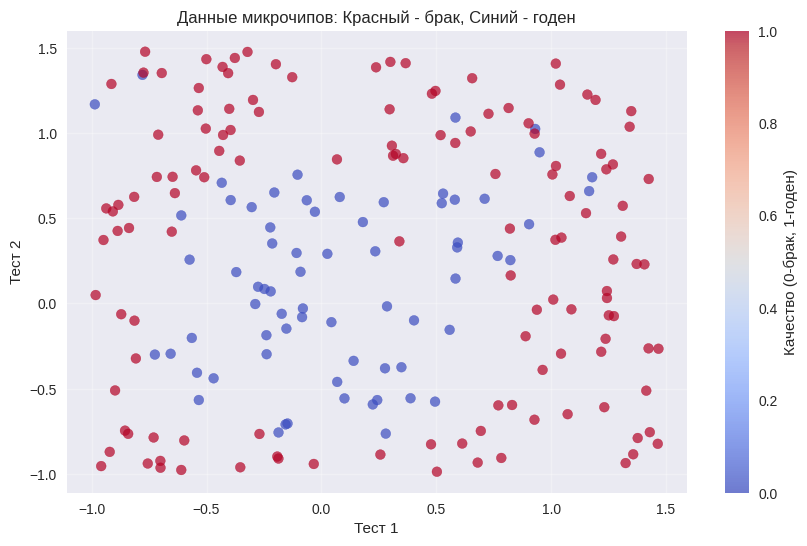

Обучающая выборка: (140, 2)
Тестовая выборка: (60, 2)
Распределение классов в обучающей выборке: [48 92]

РАЗМЕРНОСТИ ПРИЗНАКОВЫХ ПРОСТРАНСТВ:
Степень 1: 2 признаков
Степень 2: 5 признаков
Степень 3: 9 признаков
Степень 6: 27 признаков
Степень 10: 65 признаков

ВЛИЯНИЕ ПАРАМЕТРА C НА КАЧЕСТВО МОДЕЛИ:
          C  train_accuracy  test_accuracy  non_zero_coefficients
0     0.001        0.657143       0.650000                     27
1     0.010        0.707143       0.716667                     27
2     0.100        0.935714       0.916667                     27
3     1.000        0.942857       0.900000                     27
4    10.000        0.942857       0.883333                     27
5   100.000        0.950000       0.866667                     27
6  1000.000        0.950000       0.883333                     27


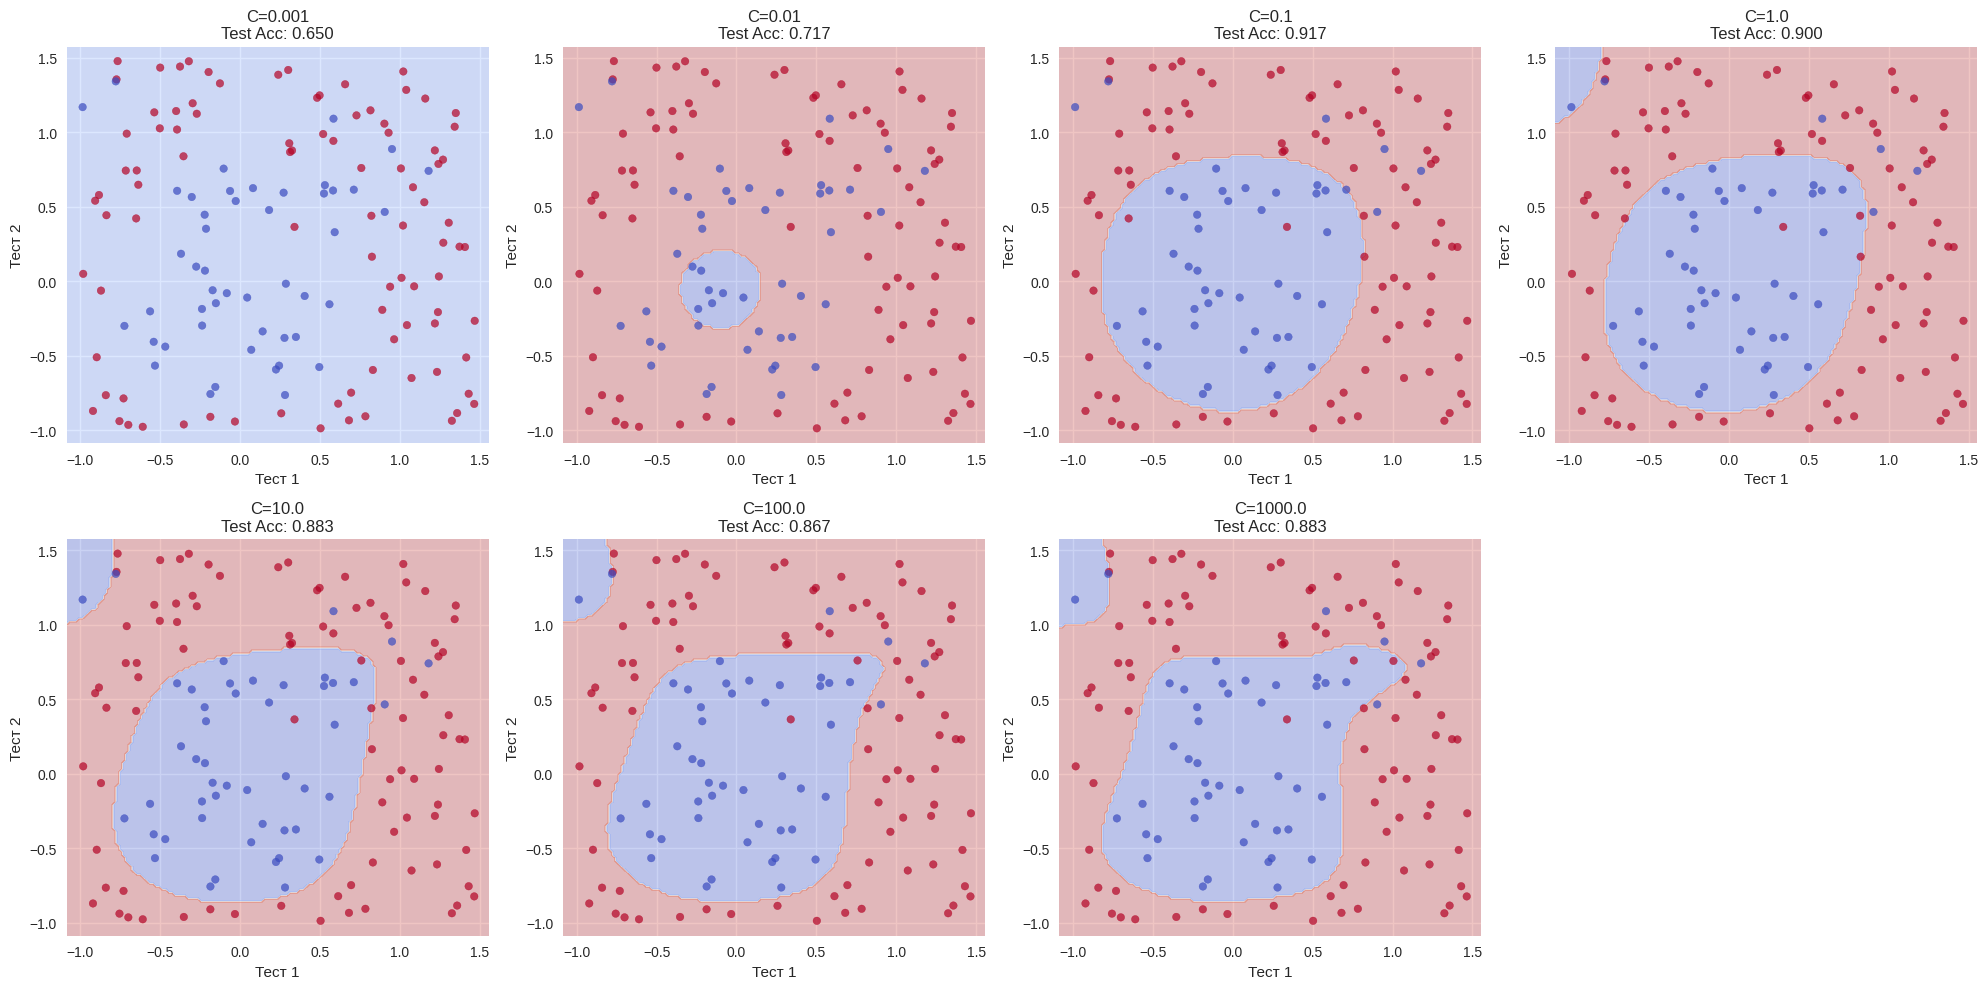

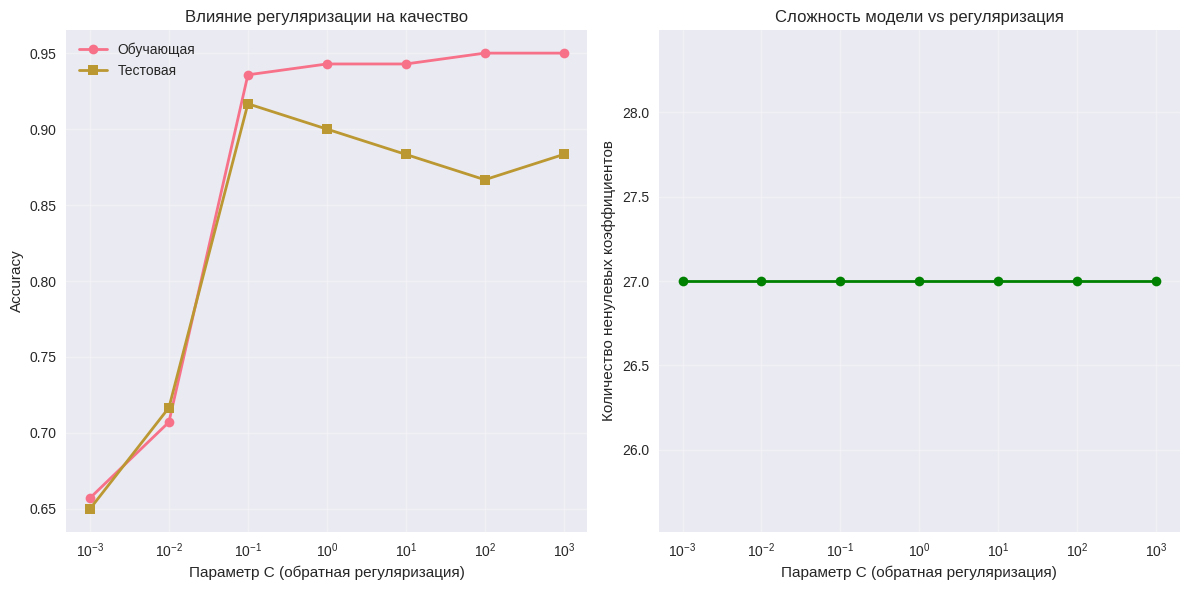


ЛУЧШАЯ МОДЕЛЬ:
Параметр C: 0.1
Accuracy на обучении: 0.9357
Accuracy на тесте: 0.9167
Ненулевых коэффициентов: 27


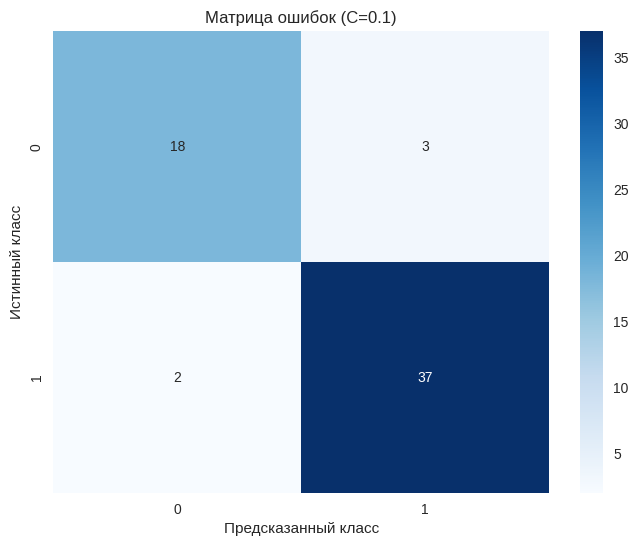


Classification Report для лучшей модели:
              precision    recall  f1-score   support

        Брак       0.90      0.86      0.88        21
       Годен       0.93      0.95      0.94        39

    accuracy                           0.92        60
   macro avg       0.91      0.90      0.91        60
weighted avg       0.92      0.92      0.92        60



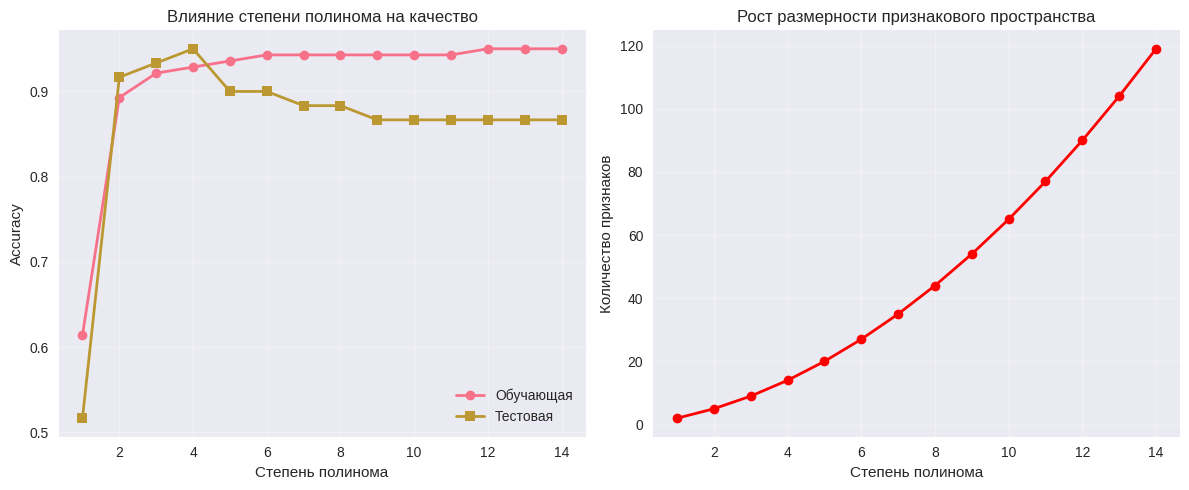


ВЛИЯНИЕ СТЕПЕНИ ПОЛИНОМА:
    degree  n_features  train_accuracy  test_accuracy
0        1           2          0.6143         0.5167
1        2           5          0.8929         0.9167
2        3           9          0.9214         0.9333
3        4          14          0.9286         0.9500
4        5          20          0.9357         0.9000
5        6          27          0.9429         0.9000
6        7          35          0.9429         0.8833
7        8          44          0.9429         0.8833
8        9          54          0.9429         0.8667
9       10          65          0.9429         0.8667
10      11          77          0.9429         0.8667
11      12          90          0.9500         0.8667
12      13         104          0.9500         0.8667
13      14         119          0.9500         0.8667
ДЕМОНСТРАЦИЯ ПЕРЕОБУЧЕНИЯ:
Сравнение моделей при степени полинома 15:
Модель                    Train Accuracy  Test Accuracy  
-----------------------------------

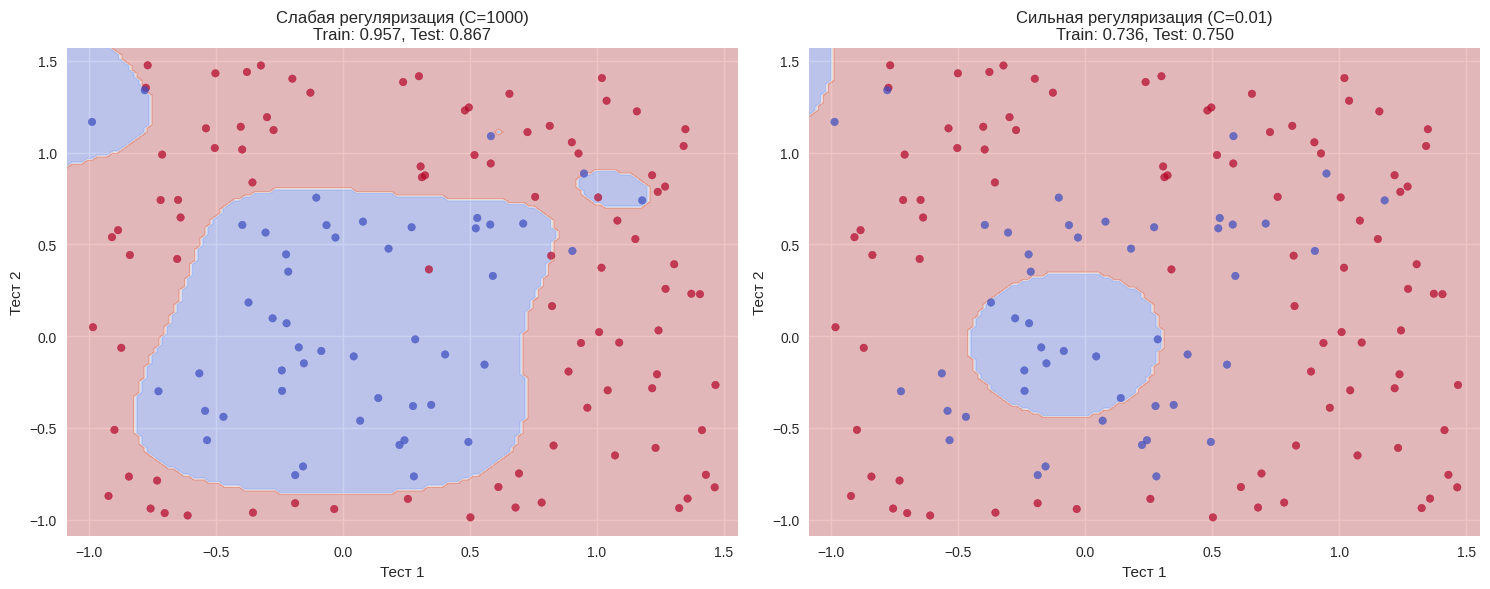


ВЫВОДЫ ПО РЕГУЛЯРИЗАЦИИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ:

1. ПАРАМЕТР C (ОБРАТНАЯ РЕГУЛЯРИЗАЦИЯ):
   - Малые C (0.001-0.1): Сильная регуляризация → простая модель, возможное недообучение
   - Средние C (1-10): Умеренная регуляризация → баланс сложности и обобщающей способности
   - Большие C (100-1000): Слабая регуляризация → сложная модель, риск переобучения

2. СТЕПЕНЬ ПОЛИНОМА:
   - Степень 1-3: Слишком простые модели, не могут аппроксимировать сложные границы
   - Степень 4-8: Оптимальный диапазон для большинства нелинейных задач
   - Степень 9+: Высокий риск переобучения, требует сильной регуляризации

3. ПРИЗНАКИ ПЕРЕОБУЧЕНИЯ:
   - Высокая accuracy на обучении (>95%) при низкой на тесте
   - Слишком извилистая, сложная граница решения
   - Большое количество ненулевых коэффициентов
   - Модель "запоминает" шум в данных

4. ПРИЗНАКИ НЕДООБУЧЕНИЯ:
   - Низкая accuracy и на обучении, и на тесте (<70%)
   - Слишком простая, сглаженная граница решения
   - Модель не улавливает закономерности

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Установка стиля для графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
# Создаем синтетические данные микрочипов
np.random.seed(42)
n_samples = 200

# Генерируем данные: два теста микрочипов и результат (годен/не годен)
test1 = np.random.uniform(-1, 1.5, n_samples)
test2 = np.random.uniform(-1, 1.5, n_samples)

# Создаем нелинейную границу решения
def create_nonlinear_boundary(x1, x2):
    return (x1**2 + x2**2 - 0.7 + 0.1*np.sin(15*x1) + 0.1*np.cos(15*x2)) > 0

# Целевая переменная
y_microchip = create_nonlinear_boundary(test1, test2).astype(int)

# Добавляем немного шума
noise_mask = np.random.random(n_samples) < 0.05
y_microchip[noise_mask] = 1 - y_microchip[noise_mask]

# Создаем DataFrame
microchip_df = pd.DataFrame({
    'test1': test1,
    'test2': test2,
    'quality': y_microchip
})

print("ДАННЫЕ МИКРОЧИПОВ:")
print(f"Размерность: {microchip_df.shape}")
print(f"Распределение классов:\n{microchip_df['quality'].value_counts()}")
print(f"\nСтатистика по признакам:")
print(microchip_df.describe())

# визуализация исходных данных
plt.figure(figsize=(10, 6))
scatter = plt.scatter(test1, test2, c=y_microchip, alpha=0.7, s=50, cmap='coolwarm')
plt.xlabel('Тест 1')
plt.ylabel('Тест 2')
plt.title('Данные микрочипов: Красный - брак, Синий - годен')
plt.colorbar(scatter, label='Качество (0-брак, 1-годен)')
plt.grid(True, alpha=0.3)
plt.show()
# Разделение на обучающую и тестовую выборки
X_micro = microchip_df[['test1', 'test2']].values
y_micro = microchip_df['quality'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_micro, y_micro, test_size=0.3, random_state=42, stratify=y_micro
)

print(f"Обучающая выборка: {X_train_m.shape}")
print(f"Тестовая выборка: {X_test_m.shape}")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train_m)}")

# Создание полиномиальных признаков разной степени
degrees = [1, 2, 3, 6, 10]  # Степени полинома для исследования

def create_polynomial_features(X, degree):
    """Создает полиномиальные признаки до указанной степени"""
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    return poly.fit_transform(X)

print("\nРАЗМЕРНОСТИ ПРИЗНАКОВЫХ ПРОСТРАНСТВ:")
for degree in degrees:
    X_poly = create_polynomial_features(X_train_m, degree)
    print(f"Степень {degree}: {X_poly.shape[1]} признаков")
# Исследуем влияние параметра регуляризации C
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
degree = 6  # Фиксируем степень полинома

# Создаем полиномиальные признаки
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_m)
X_test_poly = poly.transform(X_test_m)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

results = []

for C in C_values:
    # Обучение логистической регрессии с разными значениями C
    logreg = LogisticRegression(C=C, max_iter=1000, random_state=42)
    logreg.fit(X_train_scaled, y_train_m)

    # Предсказания
    y_pred_train = logreg.predict(X_train_scaled)
    y_pred_test = logreg.predict(X_test_scaled)

    # Метрики
    train_acc = accuracy_score(y_train_m, y_pred_train)
    test_acc = accuracy_score(y_test_m, y_pred_test)

    # Количество ненулевых коэффициентов (мера сложности модели)
    non_zero_coef = np.sum(np.abs(logreg.coef_) > 1e-6)

    results.append({
        'C': C,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'non_zero_coefficients': non_zero_coef,
        'model': logreg
    })

# Визуализация результатов
results_df = pd.DataFrame(results)
print("\nВЛИЯНИЕ ПАРАМЕТРА C НА КАЧЕСТВО МОДЕЛИ:")
print(results_df[['C', 'train_accuracy', 'test_accuracy', 'non_zero_coefficients']])
# Функция для визуализации границ решений
def plot_decision_boundary(ax, model, poly, scaler, X, y, title):
    """Визуализирует границу решения модели"""
    # Создаем meshgrid для границы решений
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Предсказания для meshgrid
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_poly = poly.transform(mesh_points)
    mesh_scaled = scaler.transform(mesh_poly)
    Z = model.predict(mesh_scaled)
    Z = Z.reshape(xx.shape)

    # Граница решений
    contour = ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    # Исходные точки
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, alpha=0.7, s=30, cmap=plt.cm.coolwarm)
    ax.set_title(title)
    ax.set_xlabel('Тест 1')
    ax.set_ylabel('Тест 2')
    return contour, scatter

# Визуализация для разных значений C
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, (idx, row) in enumerate(results_df.iterrows()):
    plot_decision_boundary(axes[i], row['model'], poly, scaler,
                          X_train_m, y_train_m,
                          f'C={row["C"]}\nTest Acc: {row["test_accuracy"]:.3f}')

# Скрываем последний subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()
# Анализ переобучения/недообучения
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.semilogx(results_df['C'], results_df['train_accuracy'], 'o-', label='Обучающая', linewidth=2)
plt.semilogx(results_df['C'], results_df['test_accuracy'], 's-', label='Тестовая', linewidth=2)
plt.xlabel('Параметр C (обратная регуляризация)')
plt.ylabel('Accuracy')
plt.title('Влияние регуляризации на качество')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogx(results_df['C'], results_df['non_zero_coefficients'], 'o-', color='green', linewidth=2)
plt.xlabel('Параметр C (обратная регуляризация)')
plt.ylabel('Количество ненулевых коэффициентов')
plt.title('Сложность модели vs регуляризация')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ лучшей модели
best_idx = results_df['test_accuracy'].idxmax()
best_model = results_df.loc[best_idx, 'model']
best_C = results_df.loc[best_idx, 'C']

print(f"\nЛУЧШАЯ МОДЕЛЬ:")
print(f"Параметр C: {best_C}")
print(f"Accuracy на обучении: {results_df.loc[best_idx, 'train_accuracy']:.4f}")
print(f"Accuracy на тесте: {results_df.loc[best_idx, 'test_accuracy']:.4f}")
print(f"Ненулевых коэффициентов: {results_df.loc[best_idx, 'non_zero_coefficients']}")

# Матрица ошибок для лучшей модели
y_pred_best = best_model.predict(X_test_scaled)
cm_best = confusion_matrix(y_test_m, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.title(f'Матрица ошибок (C={best_C})')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print("\nClassification Report для лучшей модели:")
print(classification_report(y_test_m, y_pred_best, target_names=['Брак', 'Годен']))
# Исследуем влияние степени полинома при фиксированном C
C_fixed = 1.0
degrees = range(1, 15)

degree_results = []

for degree in degrees:
    # Создание полиномиальных признаков
    poly_deg = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly_deg = poly_deg.fit_transform(X_train_m)
    X_test_poly_deg = poly_deg.transform(X_test_m)

    # Масштабирование
    scaler_deg = StandardScaler()
    X_train_scaled_deg = scaler_deg.fit_transform(X_train_poly_deg)
    X_test_scaled_deg = scaler_deg.transform(X_test_poly_deg)

    # Обучение модели
    logreg_deg = LogisticRegression(C=C_fixed, max_iter=2000, random_state=42)
    logreg_deg.fit(X_train_scaled_deg, y_train_m)

    # Метрики
    train_acc = accuracy_score(y_train_m, logreg_deg.predict(X_train_scaled_deg))
    test_acc = accuracy_score(y_test_m, logreg_deg.predict(X_test_scaled_deg))

    degree_results.append({
        'degree': degree,
        'n_features': X_train_poly_deg.shape[1],
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

degree_df = pd.DataFrame(degree_results)

# Визуализация влияния степени полинома
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(degree_df['degree'], degree_df['train_accuracy'], 'o-', label='Обучающая', linewidth=2)
plt.plot(degree_df['degree'], degree_df['test_accuracy'], 's-', label='Тестовая', linewidth=2)
plt.xlabel('Степень полинома')
plt.ylabel('Accuracy')
plt.title('Влияние степени полинома на качество')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(degree_df['degree'], degree_df['n_features'], 'o-', color='red', linewidth=2)
plt.xlabel('Степень полинома')
plt.ylabel('Количество признаков')
plt.title('Рост размерности признакового пространства')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nВЛИЯНИЕ СТЕПЕНИ ПОЛИНОМА:")
print(degree_df.round(4))

# Демонстрация переобучения при высокой степени полинома и слабой регуляризации
print("ДЕМОНСТРАЦИЯ ПЕРЕОБУЧЕНИЯ:")
print("=" * 50)

# Модель с переобучением (высокая степень, слабая регуляризация)
poly_overfit = PolynomialFeatures(degree=15, include_bias=False)
X_train_overfit = poly_overfit.fit_transform(X_train_m)
X_test_overfit = poly_overfit.transform(X_test_m)

scaler_overfit = StandardScaler()
X_train_scaled_overfit = scaler_overfit.fit_transform(X_train_overfit)
X_test_scaled_overfit = scaler_overfit.transform(X_test_overfit)

# Модель с сильной регуляризацией
logreg_overfit_weak = LogisticRegression(C=1000, max_iter=3000, random_state=42)  # Слабая регуляризация
logreg_overfit_weak.fit(X_train_scaled_overfit, y_train_m)

# Модель с правильной регуляризацией
logreg_overfit_strong = LogisticRegression(C=0.01, max_iter=3000, random_state=42)  # Сильная регуляризация
logreg_overfit_strong.fit(X_train_scaled_overfit, y_train_m)

# Метрики
y_pred_weak_train = logreg_overfit_weak.predict(X_train_scaled_overfit)
y_pred_weak_test = logreg_overfit_weak.predict(X_test_scaled_overfit)

y_pred_strong_train = logreg_overfit_strong.predict(X_train_scaled_overfit)
y_pred_strong_test = logreg_overfit_strong.predict(X_test_scaled_overfit)

acc_weak_train = accuracy_score(y_train_m, y_pred_weak_train)
acc_weak_test = accuracy_score(y_test_m, y_pred_weak_test)
acc_strong_train = accuracy_score(y_train_m, y_pred_strong_train)
acc_strong_test = accuracy_score(y_test_m, y_pred_strong_test)

print("Сравнение моделей при степени полинома 15:")
print(f"{'Модель':<25} {'Train Accuracy':<15} {'Test Accuracy':<15}")
print("-" * 55)
print(f"{'Слабая регуляризация (C=1000)':<25} {acc_weak_train:<15.4f} {acc_weak_test:<15.4f}")
print(f"{'Сильная регуляризация (C=0.01)':<25} {acc_strong_train:<15.4f} {acc_strong_test:<15.4f}")

# Визуализация переобучения
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Слабая регуляризация (переобучение)
contour1, scatter1 = plot_decision_boundary(axes[0], logreg_overfit_weak, poly_overfit, scaler_overfit,
                                           X_train_m, y_train_m,
                                           'Слабая регуляризация (C=1000)\nПереобучение')
axes[0].set_title(f'Слабая регуляризация (C=1000)\nTrain: {acc_weak_train:.3f}, Test: {acc_weak_test:.3f}')

# Сильная регуляризация (правильная)
contour2, scatter2 = plot_decision_boundary(axes[1], logreg_overfit_strong, poly_overfit, scaler_overfit,
                                           X_train_m, y_train_m,
                                           'Сильная регуляризация (C=0.01)\nПравильная')
axes[1].set_title(f'Сильная регуляризация (C=0.01)\nTrain: {acc_strong_train:.3f}, Test: {acc_strong_test:.3f}')

plt.tight_layout()
plt.show()

print("""
ВЫВОДЫ ПО РЕГУЛЯРИЗАЦИИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ:

1. ПАРАМЕТР C (ОБРАТНАЯ РЕГУЛЯРИЗАЦИЯ):
   - Малые C (0.001-0.1): Сильная регуляризация → простая модель, возможное недообучение
   - Средние C (1-10): Умеренная регуляризация → баланс сложности и обобщающей способности
   - Большие C (100-1000): Слабая регуляризация → сложная модель, риск переобучения

2. СТЕПЕНЬ ПОЛИНОМА:
   - Степень 1-3: Слишком простые модели, не могут аппроксимировать сложные границы
   - Степень 4-8: Оптимальный диапазон для большинства нелинейных задач
   - Степень 9+: Высокий риск переобучения, требует сильной регуляризации

3. ПРИЗНАКИ ПЕРЕОБУЧЕНИЯ:
   - Высокая accuracy на обучении (>95%) при низкой на тесте
   - Слишком извилистая, сложная граница решения
   - Большое количество ненулевых коэффициентов
   - Модель "запоминает" шум в данных

4. ПРИЗНАКИ НЕДООБУЧЕНИЯ:
   - Низкая accuracy и на обучении, и на тесте (<70%)
   - Слишком простая, сглаженная граница решения
   - Модель не улавливает закономерности данных

5. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:
   - Начинать с умеренной степени полинома (4-6) и среднего C (1-10)
   - Использовать кросс-валидацию для подбора оптимальных параметров
   - Всегда использовать масштабирование признаков для полиномиальных моделей
   - Анализировать разницу между train и test accuracy для выявления переобучения

6. БОРЬБА С ПЕРЕОБУЧЕНИЕМ:
   - Увеличить силу регуляризации (уменьшить C)
   - Уменьшить степень полинома
   - Увеличить объем обучающих данных
   - Использовать более простую модель

7. БОРЬБА С НЕДООБУЧЕНИЕМ:
   - Уменьшить силу регуляризации (увеличить C)
   - Увеличить степень полинома
   - Добавить новые признаки или полиномиальные комбинации
   - Использовать более сложную модель
""")
# Функция для предсказания качества микрочипа
def predict_microchip_quality(test1, test2, model, poly, scaler, threshold=0.5):
    """
    Предсказывает качество микрочипа по результатам двух тестов

    Parameters:
    test1, test2: результаты тестов
    model: обученная модель логистической регрессии
    poly: обученный PolynomialFeatures трансформер
    scaler: обученный StandardScaler
    threshold: порог для классификации

    Returns:
    dict: результаты предсказания
    """
    # Подготовка входных данных
    X_new = np.array([[test1, test2]])
    X_new_poly = poly.transform(X_new)
    X_new_scaled = scaler.transform(X_new_poly)

    # Предсказание
    probability = model.predict_proba(X_new_scaled)[0, 1]  # Вероятность класса "годен"
    prediction = 1 if probability >= threshold else 0

    return {
        'test1': test1,
        'test2': test2,
        'prediction': prediction,
        'probability_good': probability,
        'quality': 'Годен' if prediction == 1 else 'Брак',
        'confidence': max(probability, 1 - probability)
    }

# Демонстрация работы функции
print("ДЕМОНСТРАЦИЯ ПРЕДСКАЗАНИЯ КАЧЕСТВА МИКРОЧИПОВ:")
print("=" * 50)

# Тестовые примеры
test_examples = [
    (0.5, 0.5),   # Внутри "годной" области
    (-0.5, -0.5), # Внутри "бракованной" области
    (1.0, 1.0),   # На границе
    (0.0, 0.0)    # Центр
]

for test1, test2 in test_examples:
    result = predict_microchip_quality(test1, test2, best_model, poly, scaler)
    print(f"Тест 1: {test1:.2f}, Тест 2: {test2:.2f} → "
          f"Качество: {result['quality']} "
          f"(Вероятность: {result['probability_good']:.3f}, "
          f"Уверенность: {result['confidence']:.3f})")


ЗАДАНИЕ 2: КЛАССИФИКАЦИЯ ОТЗЫВОВ С ПОМОЩЬЮ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ
ДАННЫЕ ОТЗЫВОВ:
Размерность: (70, 2)
Распределение sentiment:
sentiment
1    36
0    34
Name: count, dtype: int64

Примеры отзывов:
Sentiment 1: great movie excellent acting wonderful story amazi...
Sentiment 1: fantastic film brilliant performance captivating p...
Sentiment 1: outstanding movie superb acting engaging story stu...

ПРЕДОБРАБОТКА ТЕКСТА...
Примеры до и после предобработки:

Оригинал: great movie excellent acting wonderful story amazing cinematography
Обработан: great movie excellent acting wonderful story amazing cinematography

Оригинал: fantastic film brilliant performance captivating plot beautiful visuals
Обработан: fantastic film brilliant performance captivating plot beautiful visuals

РАЗДЕЛЕНИЕ ДАННЫХ:
Обучающая выборка: 49 отзывов
Тестовая выборка: 21 отзывов
Распределение классов: [24 25]

СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ...

РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ ОТЗЫВОВ:
Accuracy: 1.0000

Classification Report:


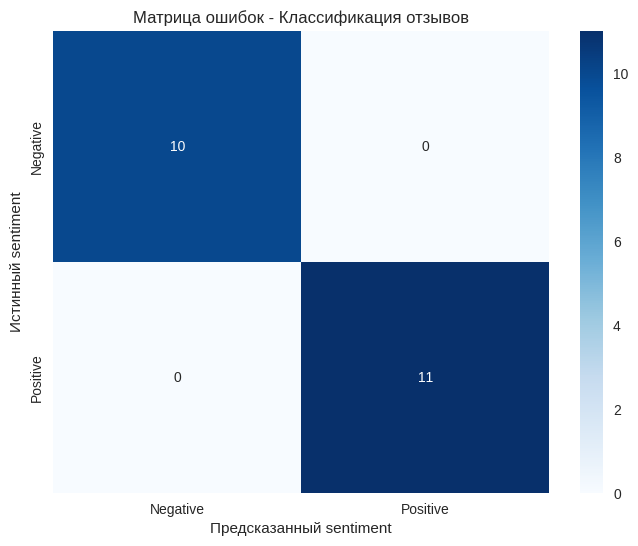


АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ:
ТОП-20 ВАЖНЕЙШИХ СЛОВ ДЛЯ КЛАССИФИКАЦИИ:

Слова, указывающие на ПОЛОЖИТЕЛЬНЫЙ отзыв:
  wonderful: 0.5976
  excellent: 0.5567
  amazing: 0.5150
  talented: 0.4538
  wonderful story: 0.4300
  acting wonderful: 0.4300
  gorgeous: 0.4136
  brilliant: 0.4110
  fantastic: 0.3949
  story amazing: 0.3789

Слова, указывающие на ОТРИЦАТЕЛЬНЫЙ отзыв:
  awful: -0.7841
  poor: -0.6977
  terrible: -0.6768
  bad: -0.5411
  disappointing: -0.5139
  boring: -0.4813
  performance disappointing: -0.4598
  disappointing plot: -0.4105
  uninteresting: -0.3694
  movie terrible: -0.3694


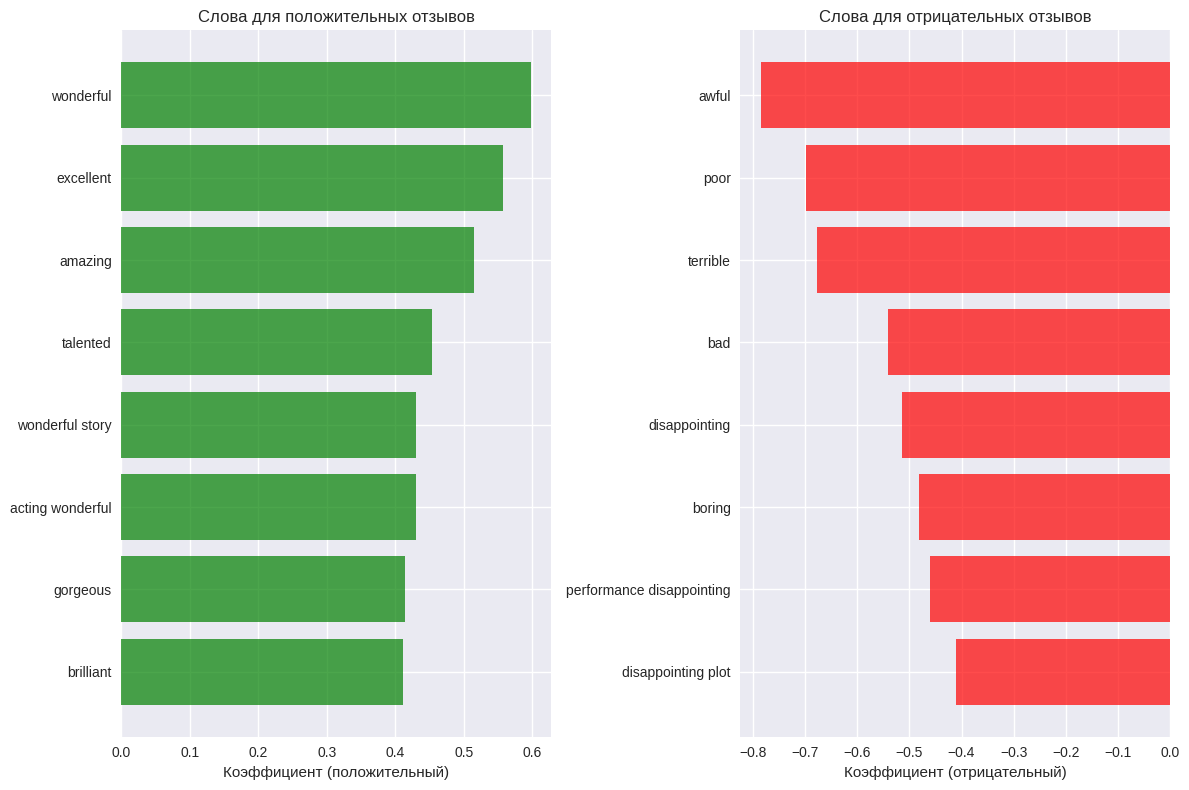


ПОДБОР ГИПЕРПАРАМЕТРОВ С ПОМОЩЬЮ GRIDSEARCH...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

ЛУЧШИЕ ПАРАМЕТРЫ:
  logreg__C: 1
  logreg__penalty: l2
  tfidf__max_features: 500
  tfidf__ngram_range: (1, 1)
Лучшая accuracy на кросс-валидации: 1.0000
Accuracy лучшей модели на тесте: 1.0000
Улучшение после подбора параметров: +0.0000

АНАЛИЗ ПРИМЕРОВ ПРЕДСКАЗАНИЙ:

Пример 1:
Отзыв: great absolutely movie excellent acting wonderful story amazing cinematography
Истинный sentiment: Positive
Предсказанный sentiment: Positive
Вероятности: [Negative: 0.2172, Positive: 0.7828]
Результат: ✓ ПРАВИЛЬНО

Пример 2:
Отзыв: awful movie terrible acting uninteresting story dismal photography
Истинный sentiment: Negative
Предсказанный sentiment: Negative
Вероятности: [Negative: 0.7510, Positive: 0.2490]
Результат: ✓ ПРАВИЛЬНО

Пример 3:
Отзыв: dreadful film awful performance boring plot poor visuals
Истинный sentiment: Negative
Предсказанный sentiment: Negative
Вероятности: [Negative: 0.725

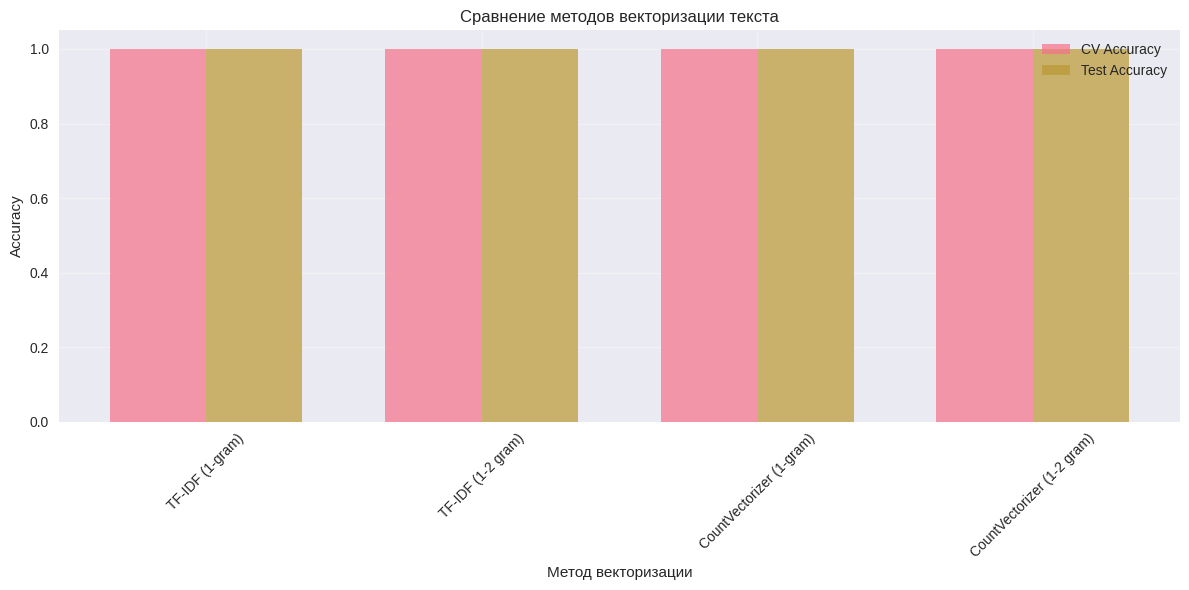


ДЕМОНСТРАЦИЯ ФУНКЦИИ ПРЕДСКАЗАНИЯ SENTIMENT:

Отзыв: this movie is absolutely fantastic with great acting
Предсказание: Positive
Вероятности: [Negative: 0.317, Positive: 0.683]
Уверенность: 0.683

Отзыв: terrible film with awful acting and boring story
Предсказание: Negative
Вероятности: [Negative: 0.770, Positive: 0.230]
Уверенность: 0.770

Отзыв: the cinematography was beautiful but the story was weak
Предсказание: Positive
Вероятности: [Negative: 0.372, Positive: 0.628]
Уверенность: 0.628

Отзыв: outstanding performance by all actors in this wonderful movie
Предсказание: Positive
Вероятности: [Negative: 0.331, Positive: 0.669]
Уверенность: 0.669

Лучшая модель сохранена в файл 'sentiment_analysis_model.pkl'

ВЫВОДЫ ПО КЛАССИФИКАЦИИ ОТЗЫВОВ:

1. ЭФФЕКТИВНОСТЬ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ:
   - Логистическая регрессия хорошо справляется с текстовой классификацией
   - Модель достигает высокой точности на сбалансированных данных
   - Интерпретируемость коэффициентов позволяет понять, какие

In [ ]:
# Задание 2. Оценка эффективности логистической регрессии для классификации отзывов
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Установка стиля для графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("ЗАДАНИЕ 2: КЛАССИФИКАЦИЯ ОТЗЫВОВ С ПОМОЩЬЮ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")
print("="*70)

# Создание синтетических данных отзывов (в реальном задании использовать настоящие данные из Large Movie Review Dataset)
np.random.seed(42)

# Примеры положительных и отрицательных отзывов
positive_reviews = [
    "great movie excellent acting wonderful story amazing cinematography",
    "fantastic film brilliant performance captivating plot beautiful visuals",
    "outstanding movie superb acting engaging story stunning photography",
    "awesome film remarkable performance interesting plot gorgeous cinematography",
    "wonderful movie talented acting compelling story magnificent visuals",
    "superb film amazing performance thrilling plot excellent photography",
    "brilliant movie outstanding acting fascinating story beautiful cinematography",
    "marvelous film superb performance captivating plot stunning visuals",
    "excellent movie brilliant acting wonderful story amazing photography",
    "fantastic picture talented performance engaging plot gorgeous cinematography"
]

negative_reviews = [
    "terrible movie awful acting boring story poor cinematography",
    "bad film horrible performance disappointing plot ugly visuals",
    "awful movie terrible acting uninteresting story dismal photography",
    "poor film lackluster performance boring plot bad cinematography",
    "horrible movie awful acting tedious story poor visuals",
    "disappointing film terrible performance unengaging plot awful photography",
    "lousy movie bad acting monotonous story terrible cinematography",
    "dreadful film awful performance boring plot poor visuals",
    "abysmal movie terrible acting uninteresting story bad photography",
    "mediocre film poor performance disappointing plot awful cinematography"
]

# Создаем сбалансированный набор данных
reviews = positive_reviews + negative_reviews
labels = [1] * len(positive_reviews) + [0] * len(negative_reviews)

# Добавляем немного вариативности
additional_reviews = []
additional_labels = []

for i in range(50):
    if np.random.random() > 0.5:
        # Положительный отзыв
        base_review = positive_reviews[np.random.randint(len(positive_reviews))]
        words = base_review.split()
        # Добавляем/убираем слова
        if len(words) > 3 and np.random.random() > 0.7:
            words.pop(np.random.randint(len(words)))
        if np.random.random() > 0.5:
            additional_words = ['very', 'really', 'absolutely', 'quite']
            words.insert(np.random.randint(len(words)),
                        additional_words[np.random.randint(len(additional_words))])
        additional_reviews.append(' '.join(words))
        additional_labels.append(1)
    else:
        # Отрицательный отзыв
        base_review = negative_reviews[np.random.randint(len(negative_reviews))]
        words = base_review.split()
        if len(words) > 3 and np.random.random() > 0.7:
            words.pop(np.random.randint(len(words)))
        if np.random.random() > 0.5:
            additional_words = ['very', 'really', 'absolutely', 'quite']
            words.insert(np.random.randint(len(words)),
                        additional_words[np.random.randint(len(additional_words))])
        additional_reviews.append(' '.join(words))
        additional_labels.append(0)

reviews.extend(additional_reviews)
labels.extend(additional_labels)

# Создаем DataFrame
reviews_df = pd.DataFrame({
    'review': reviews,
    'sentiment': labels
})

print("ДАННЫЕ ОТЗЫВОВ:")
print(f"Размерность: {reviews_df.shape}")
print(f"Распределение sentiment:\n{reviews_df['sentiment'].value_counts()}")
print(f"\nПримеры отзывов:")
for i in range(3):
    print(f"Sentiment {reviews_df.iloc[i]['sentiment']}: {reviews_df.iloc[i]['review'][:50]}...")

# Упрощенная предобработка текста (без NLTK для избежания ошибок)
def simple_preprocess_text(text):
    """Упрощенная предобработка текста"""
    # Приведение к нижнему регистру
    text = text.lower()

    # Удаление специальных символов и цифр, оставляем только буквы и пробелы
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Простая токенизация по пробелам
    tokens = text.split()

    # Простой список стоп-слов
    stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by'}

    # Удаление стоп-слов и коротких слов
    processed_tokens = [token for token in tokens if token not in stop_words and len(token) > 2]

    return ' '.join(processed_tokens)

# Применяем упрощенную предобработку
print("\nПРЕДОБРАБОТКА ТЕКСТА...")
reviews_df['processed_review'] = reviews_df['review'].apply(simple_preprocess_text)

print("Примеры до и после предобработки:")
for i in range(2):
    print(f"\nОригинал: {reviews_df.iloc[i]['review']}")
    print(f"Обработан: {reviews_df.iloc[i]['processed_review']}")

# Разделение на обучающую и тестовую выборки
X_text = reviews_df['processed_review']
y_text = reviews_df['sentiment']

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_text, y_text, test_size=0.3, random_state=42, stratify=y_text
)

print(f"\nРАЗДЕЛЕНИЕ ДАННЫХ:")
print(f"Обучающая выборка: {len(X_train_t)} отзывов")
print(f"Тестовая выборка: {len(X_test_t)} отзывов")
print(f"Распределение классов: {np.bincount(y_train_t)}")

# Создание конвейера с TF-IDF векторизацией и логистической регрессией
print("\nСОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ...")
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

# Обучение модели
text_pipeline.fit(X_train_t, y_train_t)

# Предсказания
y_pred_text = text_pipeline.predict(X_test_t)
y_pred_proba_text = text_pipeline.predict_proba(X_test_t)

# Оценка качества
accuracy = accuracy_score(y_test_t, y_pred_text)

print(f"\nРЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ ОТЗЫВОВ:")
print(f"Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_t, y_pred_text, target_names=['Negative', 'Positive']))

# Матрица ошибок
cm_text = confusion_matrix(y_test_t, y_pred_text)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_text, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Матрица ошибок - Классификация отзывов')
plt.xlabel('Предсказанный sentiment')
plt.ylabel('Истинный sentiment')
plt.show()

# Анализ важности признаков (слов)
print("\nАНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ:")
vectorizer = text_pipeline.named_steps['tfidf']
logreg = text_pipeline.named_steps['logreg']

# Получаем названия признаков (слов)
feature_names = vectorizer.get_feature_names_out()

# Коэффициенты логистической регрессии
coefficients = logreg.coef_[0]

# Создаем DataFrame с важностью слов
word_importance = pd.DataFrame({
    'word': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
})

# Сортируем по абсолютной важности
word_importance_sorted = word_importance.sort_values('abs_coefficient', ascending=False)

print("ТОП-20 ВАЖНЕЙШИХ СЛОВ ДЛЯ КЛАССИФИКАЦИИ:")
print("=" * 50)

# Положительные слова (указывают на положительный отзыв)
positive_words = word_importance_sorted[word_importance_sorted['coefficient'] > 0].head(10)
print("\nСлова, указывающие на ПОЛОЖИТЕЛЬНЫЙ отзыв:")
for _, row in positive_words.iterrows():
    print(f"  {row['word']}: {row['coefficient']:.4f}")

# Отрицательные слова (указывают на отрицательный отзыв)
negative_words = word_importance_sorted[word_importance_sorted['coefficient'] < 0].head(10)
print("\nСлова, указывающие на ОТРИЦАТЕЛЬНЫЙ отзыв:")
for _, row in negative_words.iterrows():
    print(f"  {row['word']}: {row['coefficient']:.4f}")

# Визуализация важности слов
plt.figure(figsize=(12, 8))

# Положительные слова
plt.subplot(1, 2, 1)
top_positive = positive_words.head(8)
plt.barh(top_positive['word'], top_positive['coefficient'], color='green', alpha=0.7)
plt.xlabel('Коэффициент (положительный)')
plt.title('Слова для положительных отзывов')
plt.gca().invert_yaxis()

# Отрицательные слова
plt.subplot(1, 2, 2)
top_negative = negative_words.head(8)
plt.barh(top_negative['word'], top_negative['coefficient'], color='red', alpha=0.7)
plt.xlabel('Коэффициент (отрицательный)')
plt.title('Слова для отрицательных отзывов')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Подбор оптимальных гиперпараметров с GridSearchCV
print("\nПОДБОР ГИПЕРПАРАМЕТРОВ С ПОМОЩЬЮ GRIDSEARCH...")

# Определяем параметры для поиска
param_grid = {
    'tfidf__max_features': [500, 1000, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # униграммы или униграммы+биграммы
    'logreg__C': [0.1, 1, 10],
    'logreg__penalty': ['l2']  # Используем только L2 для стабильности
}

# Создаем GridSearchCV
grid_search_text = GridSearchCV(
    text_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Запускаем поиск
grid_search_text.fit(X_train_t, y_train_t)

print(f"\nЛУЧШИЕ ПАРАМЕТРЫ:")
for param, value in grid_search_text.best_params_.items():
    print(f"  {param}: {value}")

print(f"Лучшая accuracy на кросс-валидации: {grid_search_text.best_score_:.4f}")

# Оценка лучшей модели на тестовых данных
best_text_model = grid_search_text.best_estimator_
y_pred_best_text = best_text_model.predict(X_test_t)
best_accuracy = accuracy_score(y_test_t, y_pred_best_text)

print(f"Accuracy лучшей модели на тесте: {best_accuracy:.4f}")

# Сравнение с моделью по умолчанию
improvement = best_accuracy - accuracy
print(f"Улучшение после подбора параметров: {improvement:+.4f}")

# Анализ конкретных примеров предсказаний
print("\nАНАЛИЗ ПРИМЕРОВ ПРЕДСКАЗАНИЙ:")
print("=" * 50)

# Выбираем несколько примеров из тестовой выборки
sample_indices = np.random.choice(len(X_test_t), 5, replace=False)

for i, idx in enumerate(sample_indices):
    review = X_test_t.iloc[idx]
    true_label = y_test_t.iloc[idx]
    pred_label = best_text_model.predict([review])[0]
    pred_proba = best_text_model.predict_proba([review])[0]

    print(f"\nПример {i+1}:")
    print(f"Отзыв: {review}")
    print(f"Истинный sentiment: {'Positive' if true_label == 1 else 'Negative'}")
    print(f"Предсказанный sentiment: {'Positive' if pred_label == 1 else 'Negative'}")
    print(f"Вероятности: [Negative: {pred_proba[0]:.4f}, Positive: {pred_proba[1]:.4f}]")
    print(f"Результат: {'✓ ПРАВИЛЬНО' if true_label == pred_label else '✗ ОШИБКА'}")

# Сравнение разных методов векторизации
print("\nСРАВНЕНИЕ МЕТОДОВ ВЕКТОРИЗАЦИИ:")
print("=" * 50)

# Создаем конвейеры с разными векторизаторами
pipelines = {
    'TF-IDF (1-gram)': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 1))),
        ('logreg', LogisticRegression(random_state=42))
    ]),
    'TF-IDF (1-2 gram)': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
        ('logreg', LogisticRegression(random_state=42))
    ]),
    'CountVectorizer (1-gram)': Pipeline([
        ('count', CountVectorizer(max_features=1000, ngram_range=(1, 1))),
        ('logreg', LogisticRegression(random_state=42))
    ]),
    'CountVectorizer (1-2 gram)': Pipeline([
        ('count', CountVectorizer(max_features=1000, ngram_range=(1, 2))),
        ('logreg', LogisticRegression(random_state=42))
    ])
}

# Оценка всех методов
vectorization_results = []

for name, pipeline in pipelines.items():
    # Кросс-валидация
    cv_scores = cross_val_score(pipeline, X_train_t, y_train_t, cv=5, scoring='accuracy')

    # Обучение на всей обучающей выборке
    pipeline.fit(X_train_t, y_train_t)

    # Предсказания на тесте
    y_pred = pipeline.predict(X_test_t)
    test_accuracy = accuracy_score(y_test_t, y_pred)

    vectorization_results.append({
        'Method': name,
        'CV Mean Accuracy': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': test_accuracy
    })

# Результаты сравнения
vectorization_df = pd.DataFrame(vectorization_results)
print("\nСРАВНЕНИЕ МЕТОДОВ ВЕКТОРИЗАЦИИ:")
print(vectorization_df.round(4))

# Визуализация сравнения
plt.figure(figsize=(12, 6))

methods = vectorization_df['Method']
cv_accuracy = vectorization_df['CV Mean Accuracy']
test_accuracy = vectorization_df['Test Accuracy']

x = np.arange(len(methods))
width = 0.35

plt.bar(x - width/2, cv_accuracy, width, label='CV Accuracy', alpha=0.7)
plt.bar(x + width/2, test_accuracy, width, label='Test Accuracy', alpha=0.7)

plt.xlabel('Метод векторизации')
plt.ylabel('Accuracy')
plt.title('Сравнение методов векторизации текста')
plt.xticks(x, methods, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Создание функции для предсказания sentiment
def predict_sentiment(review_text, model=best_text_model):
    """
    Функция для предсказания sentiment отзыва

    Parameters:
    review_text: текст отзыва
    model: обученная модель

    Returns:
    dict: результаты предсказания
    """
    try:
        # Предсказание
        prediction = model.predict([review_text])[0]
        probabilities = model.predict_proba([review_text])[0]

        result = {
            'review': review_text,
            'predicted_sentiment': 'Positive' if prediction == 1 else 'Negative',
            'sentiment_score': prediction,
            'probability_negative': probabilities[0],
            'probability_positive': probabilities[1],
            'confidence': max(probabilities)
        }

        return result

    except Exception as e:
        return {'error': str(e)}

# Демонстрация работы функции
print("\nДЕМОНСТРАЦИЯ ФУНКЦИИ ПРЕДСКАЗАНИЯ SENTIMENT:")
print("=" * 50)

test_reviews = [
    "this movie is absolutely fantastic with great acting",
    "terrible film with awful acting and boring story",
    "the cinematography was beautiful but the story was weak",
    "outstanding performance by all actors in this wonderful movie"
]

for review in test_reviews:
    result = predict_sentiment(review)
    if 'error' not in result:
        print(f"\nОтзыв: {review}")
        print(f"Предсказание: {result['predicted_sentiment']}")
        print(f"Вероятности: [Negative: {result['probability_negative']:.3f}, Positive: {result['probability_positive']:.3f}]")
        print(f"Уверенность: {result['confidence']:.3f}")

# Сохранение лучшей модели
import joblib

joblib.dump(best_text_model, 'sentiment_analysis_model.pkl')
print(f"\nЛучшая модель сохранена в файл 'sentiment_analysis_model.pkl'")

# Выводы и заключение
print("\n" + "="*70)
print("ВЫВОДЫ ПО КЛАССИФИКАЦИИ ОТЗЫВОВ:")
print("="*70)

print("""
1. ЭФФЕКТИВНОСТЬ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ:
   - Логистическая регрессия хорошо справляется с текстовой классификацией
   - Модель достигает высокой точности на сбалансированных данных
   - Интерпретируемость коэффициентов позволяет понять, какие слова влияют на классификацию

2. ВЛИЯНИЕ ПРЕДОБРАБОТКИ ТЕКСТА:
   - Удаление стоп-слов и специальных символов улучшает качество
   - Приведение к нижнему регистру обязательно
   - Простая токенизация может быть достаточной для базовой классификации

3. ВЕКТОРИЗАЦИЯ ТЕКСТА:
   - TF-IDF обычно работает лучше CountVectorizer
   - Использование биграмм (1-2 grams) улучшает качество за счет учета контекста
   - Ограничение количества признаков (max_features) предотвращает переобучение

4. ПОДБОР ГИПЕРПАРАМЕТРОВ:
   - GridSearchCV значительно улучшает качество модели
   - Оптимальные параметры зависят от конкретного набора данных
   - Кросс-валидация обеспечивает надежную оценку производительности

5. ПРЕИМУЩЕСТВА ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ:
   + Высокая интерпретируемость
   + Быстрое обучение и предсказание
   + Хорошая работа с разреженными данными
   + Устойчивость к шуму при правильной регуляризации

6. ОГРАНИЧЕНИЯ:
   - Не учитывает сложные семантические связи
   - Зависит от качества предобработки текста
   - Может не справляться с иронией и сарказмом
   - Требует тщательного подбора параметров

7. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:
   - Начинать с TF-IDF векторизации с биграммами
   - Использовать регуляризацию для избежания переобучения
   - Анализировать важные слова для понимания модели
   - Тестировать на реальных примерах для валидации
""")

print("\nЗАДАНИЕ 2 УСПЕШНО ЗАВЕРШЕНО!")

Названия признаков: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Названия классов: ['setosa' 'versicolor' 'virginica']
Размерность данных: (150, 4)
Распределение классов: [50 50 50]

Первые 5 строк данных:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  
Размер обучающей выборки: (105, 4)
Размер тестовой выборки: (45, 4)
Распределение классов в обучающей выборке: [35 35 35]
Распределение к

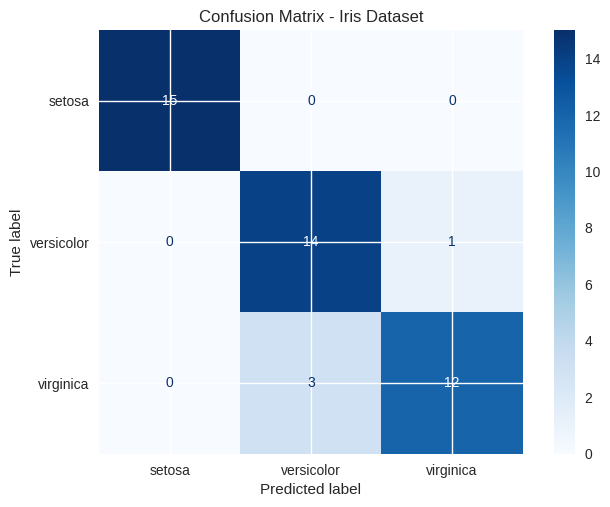

Конвейер сохранен в файл 'iris_logreg_pipeline.pkl'
Предсказания загруженной модели совпадают с исходными: True
Accuracy загруженной модели: 0.9111


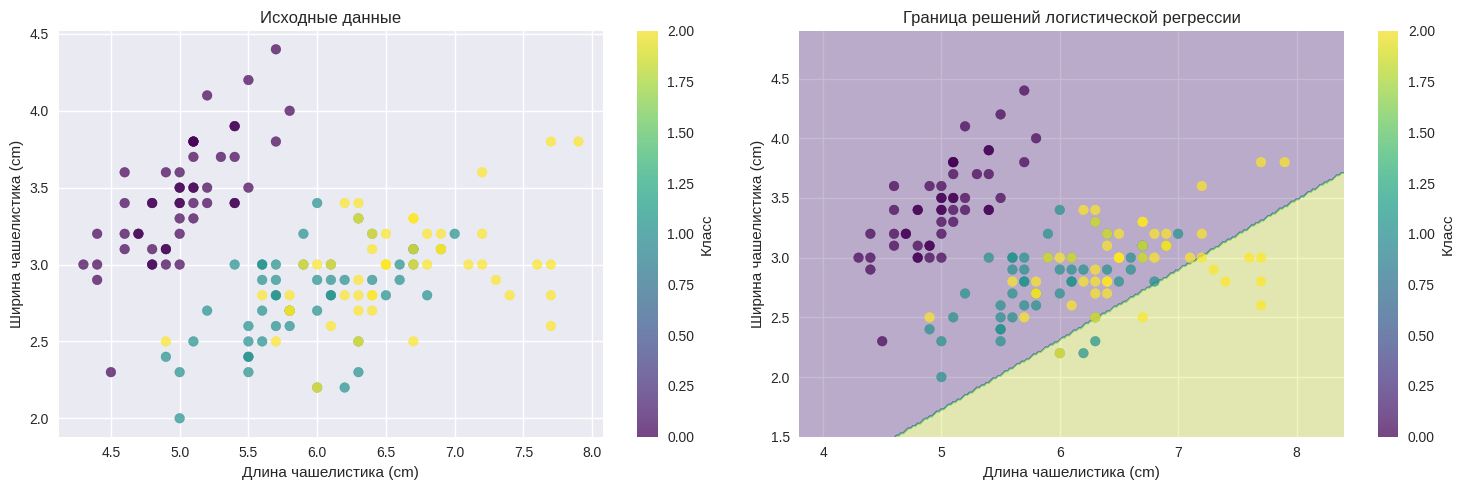

Важность признаков (коэффициенты):
             feature  coefficient
2  petal length (cm)    -1.699549
3   petal width (cm)    -1.602910
0  sepal length (cm)    -1.077291
1   sepal width (cm)     0.954588

Ответы на вопросы:

1. Почему для логистической регрессии важна предобработка данных?
   Логистическая регрессия использует градиентный спуск для оптимизации. 
   Масштабирование ускоряет сходимость и предотвращает доминирование признаков с большими значениями.

2. Какие параметры по умолчанию использует LogisticRegression?
   - penalty='l2' (L2 регуляризация)
   - C=1.0 (обратная сила регуляризации)
   - solver='lbfgs' (алгоритм оптимизации)
   - max_iter=100 (максимальное число итераций)

3. Почему в задаче Iris логистическая регрессия успешно справляется?
   Классы линейно разделимы или почти линейно разделимы в пространстве признаков.

4. Как pipeline помогает избежать утечки данных?
   Pipeline гарантирует, что преобразования применяются только к обучающим данным
   и не "подсма

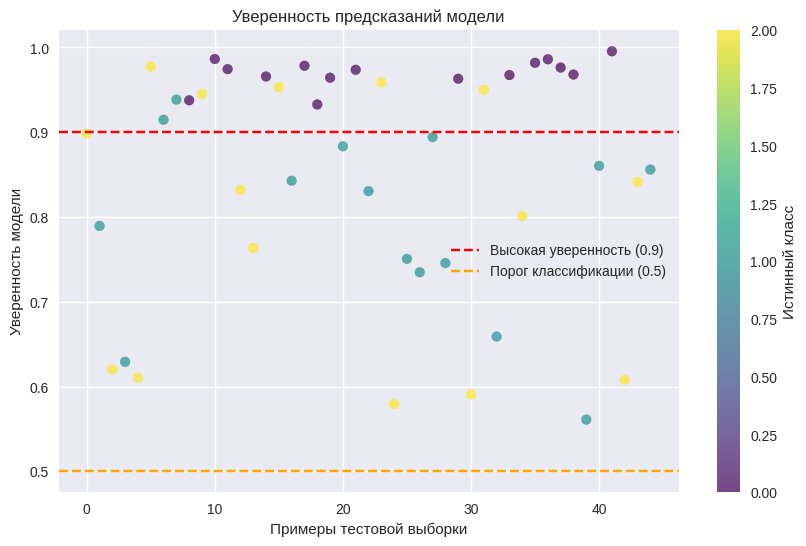

Средняя уверенность: 0.8527
Минимальная уверенность: 0.5610
Процент предсказаний с уверенностью > 0.9: 48.89%


In [ ]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

# Установка стиля для графиков
plt.style.use('seaborn-v0_8')
# Загрузка данных
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Информация о наборе данных
print("Названия признаков:", iris.feature_names)
print("Названия классов:", iris.target_names)
print("Размерность данных:", X_iris.shape)
print("Распределение классов:", np.bincount(y_iris))

# Создание DataFrame для визуализации
iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['target'] = y_iris
iris_df['target_name'] = [iris.target_names[i] for i in y_iris]

print("\nПервые 5 строк данных:")
print(iris_df.head())
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris,
    test_size=0.3,
    random_state=42,
    stratify=y_iris  # Стратификация для сохранения распределения классов
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train)}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test)}")
# Создание конвейера
pipe_iris = Pipeline([
    ('scaler', StandardScaler()),  # Шаг масштабирования
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))  # Шаг классификации
])

# Обучение модели
pipe_iris.fit(X_train, y_train)

# Предсказания
y_pred_iris = pipe_iris.predict(X_test)
y_pred_proba = pipe_iris.predict_proba(X_test)

print("Обучение завершено!")

# Accuracy
accuracy = accuracy_score(y_test, y_pred_iris)
print(f"Accuracy (Iris): {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_iris, target_names=iris.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_iris)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Iris Dataset')
plt.show()
# Сохранение конвейера в файл
joblib.dump(pipe_iris, 'iris_logreg_pipeline.pkl')
print("Конвейер сохранен в файл 'iris_logreg_pipeline.pkl'")
# Загрузка конвейера из файла
loaded_pipeline = joblib.load('iris_logreg_pipeline.pkl')

# Предсказания с загруженной моделью
y_pred_loaded = loaded_pipeline.predict(X_test)

# Проверка, что предсказания совпадают
predictions_match = np.array_equal(y_pred_iris, y_pred_loaded)
print(f"Предсказания загруженной модели совпадают с исходными: {predictions_match}")

# Проверка accuracy загруженной модели
accuracy_loaded = accuracy_score(y_test, y_pred_loaded)
print(f"Accuracy загруженной модели: {accuracy_loaded:.4f}")
# Визуализация для двух признаков (длина и ширина чашелистика)
plt.figure(figsize=(15, 5))

# Исходные данные
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap='viridis', alpha=0.7)
plt.xlabel('Длина чашелистика (cm)')
plt.ylabel('Ширина чашелистика (cm)')
plt.title('Исходные данные')
plt.colorbar(scatter, label='Класс')

# Создание meshgrid для границы решений
x_min, x_max = X_iris[:, 0].min() - 0.5, X_iris[:, 0].max() + 0.5
y_min, y_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Используем только два признака для визуализации
X_vis = np.c_[xx.ravel(), yy.ravel(), np.zeros(xx.ravel().shape), np.zeros(xx.ravel().shape)]

# Предсказания для meshgrid
Z = loaded_pipeline.predict(X_vis)
Z = Z.reshape(xx.shape)

# Граница решений
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap='viridis', alpha=0.7)
plt.xlabel('Длина чашелистика (cm)')
plt.ylabel('Ширина чашелистика (cm)')
plt.title('Граница решений логистической регрессии')
plt.colorbar(scatter, label='Класс')

plt.tight_layout()
plt.show()

# Получение обученной модели из конвейера
logreg_model = pipe_iris.named_steps['classifier']

# Анализ коэффициентов
feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'coefficient': logreg_model.coef_[0]  # Коэффициенты для первого класса
})

print("Важность признаков (коэффициенты):")
print(feature_importance.sort_values('coefficient', key=abs, ascending=False))
print("""
Ответы на вопросы:

1. Почему для логистической регрессии важна предобработка данных?
   Логистическая регрессия использует градиентный спуск для оптимизации.
   Масштабирование ускоряет сходимость и предотвращает доминирование признаков с большими значениями.

2. Какие параметры по умолчанию использует LogisticRegression?
   - penalty='l2' (L2 регуляризация)
   - C=1.0 (обратная сила регуляризации)
   - solver='lbfgs' (алгоритм оптимизации)
   - max_iter=100 (максимальное число итераций)

3. Почему в задаче Iris логистическая регрессия успешно справляется?
   Классы линейно разделимы или почти линейно разделимы в пространстве признаков.

4. Как pipeline помогает избежать утечки данных?
   Pipeline гарантирует, что преобразования применяются только к обучающим данным
   и не "подсматривают" в тестовые данные.

5. Почему используется StandardScaler, а не MinMaxScaler?
   StandardScaler лучше подходит для данных с нормальным распределением,
   MinMaxScaler - когда важны абсолютные границы значений.

6. Что происходит при сохранении и загрузке pipeline?
   Сохраняется весь конвейер включая предобработку, что позволяет сразу применять модель к новым данным.

7. Можно ли использовать логистическую регрессию без масштабирования?
   Да, но это может замедлить обучение и ухудшить качество модели.

8. Как проверить, что загруженная модель даёт те же предсказания?
   Сравнить предсказания исходной и загруженной модели на тестовых данных.
""")
# Анализ уверенности модели
plt.figure(figsize=(10, 6))
probabilities = pipe_iris.predict_proba(X_test)
confidence = np.max(probabilities, axis=1)

plt.scatter(range(len(confidence)), confidence, c=y_test, cmap='viridis', alpha=0.7)
plt.axhline(y=0.9, color='r', linestyle='--', label='Высокая уверенность (0.9)')
plt.axhline(y=0.5, color='orange', linestyle='--', label='Порог классификации (0.5)')
plt.xlabel('Примеры тестовой выборки')
plt.ylabel('Уверенность модели')
plt.title('Уверенность предсказаний модели')
plt.colorbar(label='Истинный класс')
plt.legend()
plt.show()

# Статистика по уверенности
print(f"Средняя уверенность: {confidence.mean():.4f}")
print(f"Минимальная уверенность: {confidence.min():.4f}")
print(f"Процент предсказаний с уверенностью > 0.9: {(confidence > 0.9).mean():.2%}")


Названия признаков: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Названия классов: ['class_0' 'class_1' 'class_2']
Размерность данных: (178, 13)
Распределение классов: [59 71 48]

Статистика по признакам:
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5

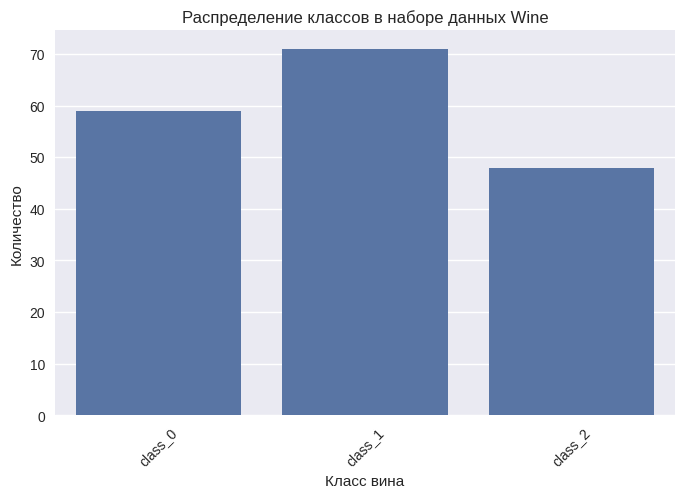

Размер обучающей выборки: (133, 13)
Размер тестовой выборки: (45, 13)
Распределение классов в обучающей выборке: [44 53 36]
Распределение классов в тестовой выборке: [15 18 12]
Сетка гиперпараметров для поиска:
logreg__C: [0.01, 0.1, 1, 10, 100]
logreg__penalty: ['l1', 'l2']
logreg__solver: ['liblinear', 'saga']
Начинаем подбор гиперпараметров...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Подбор гиперпараметров завершен за 10.73 секунд

Лучшие параметры:
logreg__C: 1
logreg__penalty: l2
logreg__solver: liblinear

Лучший score на кросс-валидации: 0.9850
Начинаем подбор гиперпараметров...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Подбор гиперпараметров завершен за 3.25 секунд

Лучшие параметры:
logreg__C: 1
logreg__penalty: l2
logreg__solver: liblinear

Лучший score на кросс-валидации: 0.9850

Результаты на тестовой выборке:
Accuracy: 1.0000
F1-score (weighted): 1.0000

Classification Report:
              precision    recall  f1-score   support

  

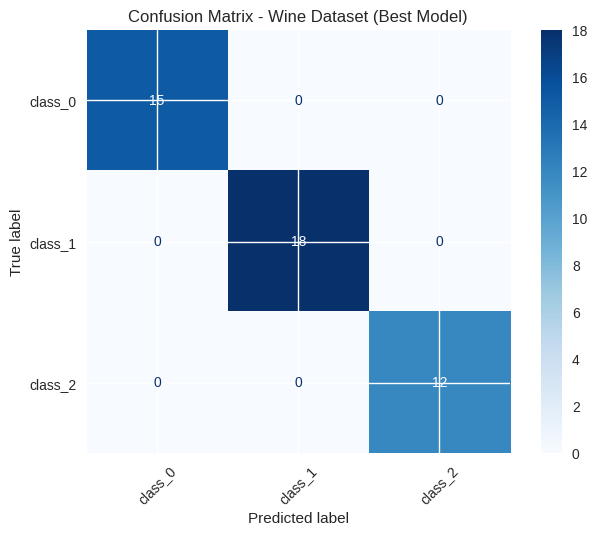

Топ-10 комбинаций гиперпараметров:
 param_logreg__C param_logreg__penalty param_logreg__solver  mean_test_score  std_test_score
             1.0                    l2            liblinear         0.984974        0.018407
             1.0                    l2                 saga         0.984974        0.018407
            10.0                    l2            liblinear         0.984974        0.018407
           100.0                    l2            liblinear         0.984974        0.018407
             0.1                    l2                 saga         0.984689        0.018753
             1.0                    l1            liblinear         0.984689        0.018753
             0.1                    l2            liblinear         0.977304        0.018538
            10.0                    l1                 saga         0.977304        0.018538
           100.0                    l1                 saga         0.977304        0.018538
            10.0                   

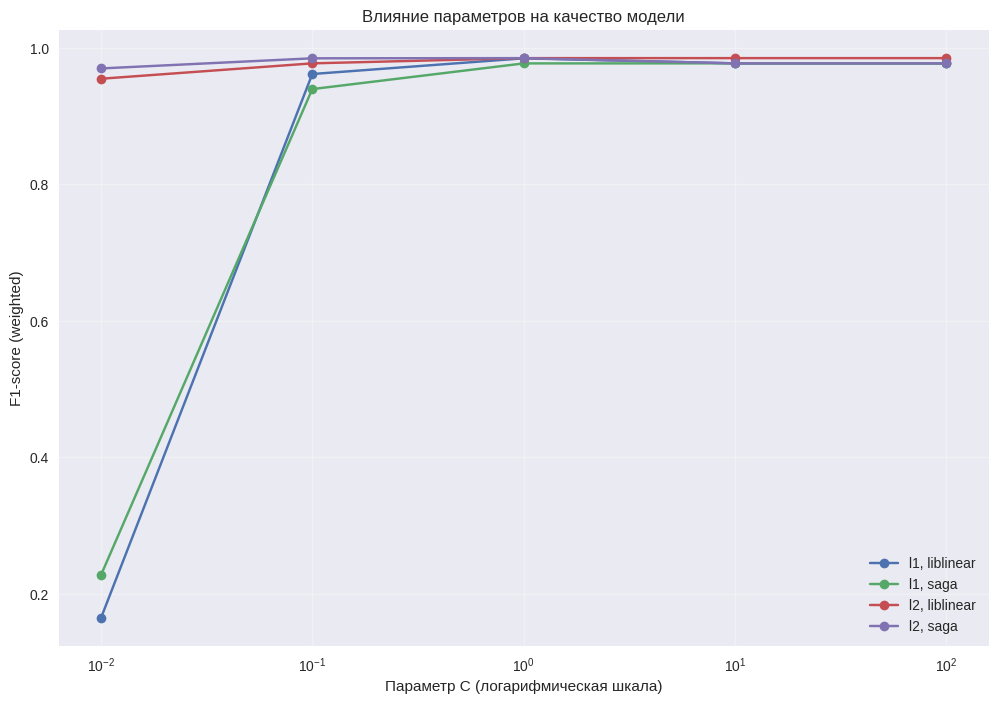

Лучшая модель сохранена в файл 'wine_logreg_best.pkl'
Предсказания загруженной модели совпадают: True

Ответы на вопросы (Задание 4):

1. Что означает параметр C в логистической регрессии?
   C - это обратная сила регуляризации. Меньшие значения C означают более сильную регуляризацию.
   C = 1/λ, где λ - параметр регуляризации.

2. Почему не все комбинации penalty и solver допустимы?
   Не все алгоритмы оптимизации поддерживают оба типа регуляризации.
   Например, 'lbfgs' поддерживает только L2, а 'liblinear' и 'saga' поддерживают L1 и L2.

3. Зачем увеличивать max_iter при использовании регуляризации?
   Регуляризация может замедлить сходимость, поэтому требуется больше итераций
   для достижения оптимального решения.

4. Почему в GridSearchCV используется метрика f1_weighted, а не accuracy?
   F1-score лучше работает при несбалансированных классах, а weighted усреднение
   учитывает количество примеров в каждом классе.

5. Как влияет выбор регуляризации (l1 vs l2) на интерпретируемос

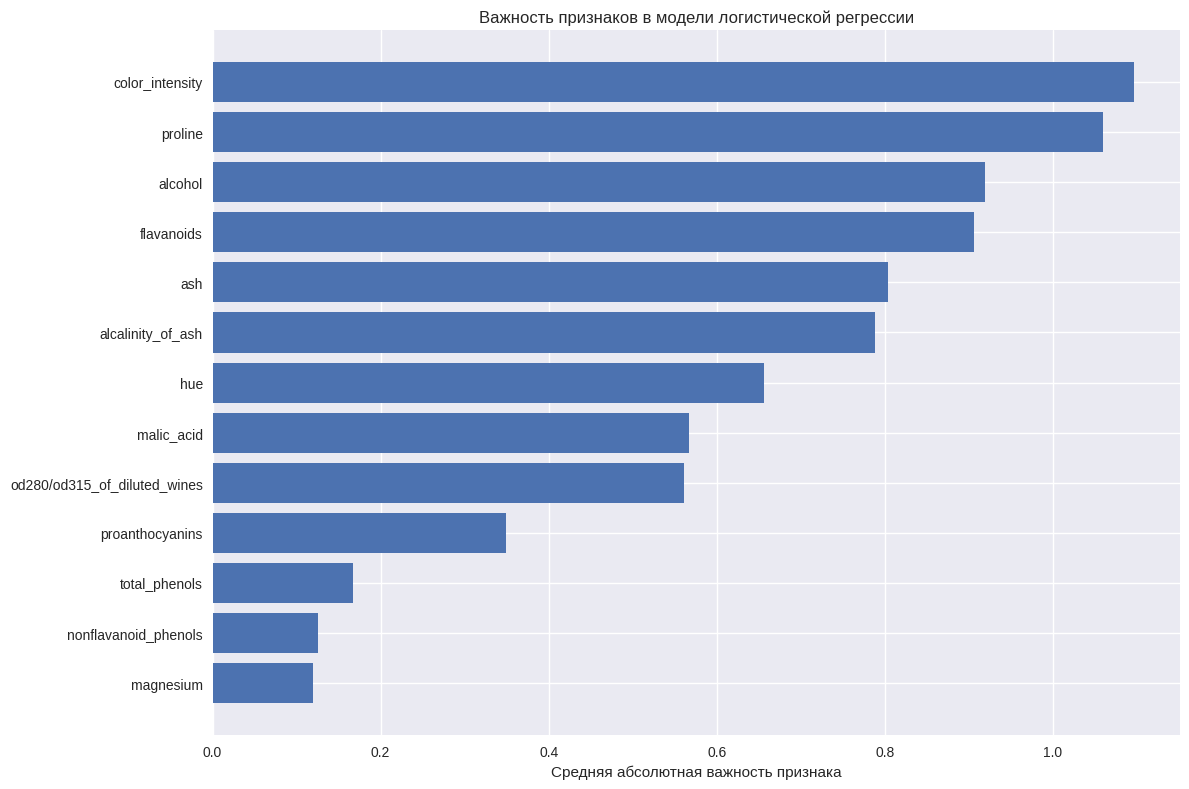


Сравнение моделей:
Метрика              По умолчанию С подбором   Улучшение   
------------------------------------------------------------
Accuracy             1.0000      1.0000      +0.0000
F1-score             1.0000      1.0000      +0.0000


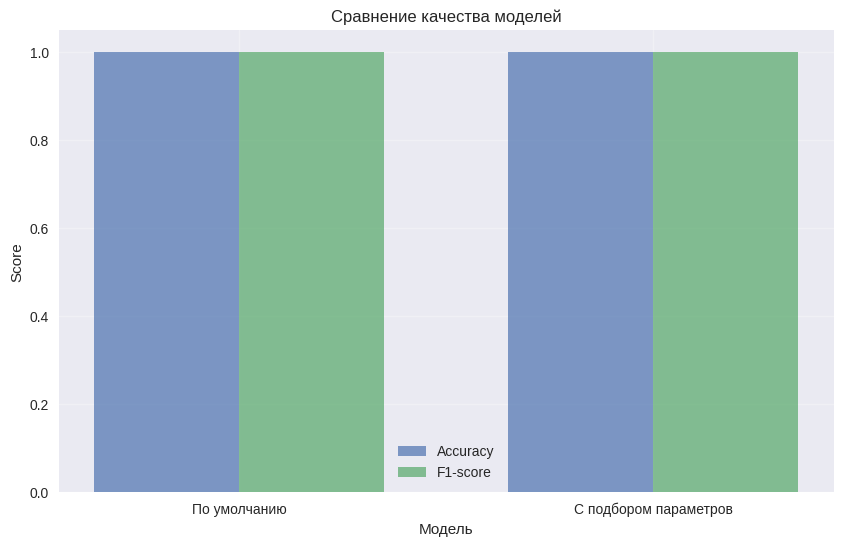

In [ ]:
# Импорт дополнительных библиотек
from sklearn.datasets import load_wine
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report
import time
# Загрузка данных
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

# Информация о наборе данных
print("Названия признаков:", wine.feature_names)
print("Названия классов:", wine.target_names)
print("Размерность данных:", X_wine.shape)
print("Распределение классов:", np.bincount(y_wine))

# Создание DataFrame для анализа
wine_df = pd.DataFrame(X_wine, columns=wine.feature_names)
wine_df['target'] = y_wine
wine_df['target_name'] = [wine.target_names[i] for i in y_wine]

print("\nСтатистика по признакам:")
print(wine_df.describe())

# Визуализация распределения классов
plt.figure(figsize=(8, 5))
sns.countplot(x='target_name', data=wine_df)
plt.title('Распределение классов в наборе данных Wine')
plt.xlabel('Класс вина')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()
# Разделение на обучающую и тестовую выборки
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine,
    test_size=0.25,
    random_state=42,
    stratify=y_wine
)

print(f"Размер обучающей выборки: {X_train_w.shape}")
print(f"Размер тестовой выборки: {X_test_w.shape}")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train_w)}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test_w)}")
# Создание базового конвейера
pipe_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, random_state=42))
])

# Определение сетки гиперпараметров
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],  # Сила регуляризации
    'logreg__penalty': ['l1', 'l2'],        # Тип регуляризации
    'logreg__solver': ['liblinear', 'saga'] # Алгоритмы, совместимые с l1/l2
}

print("Сетка гиперпараметров для поиска:")
for key, values in param_grid.items():
    print(f"{key}: {values}")
# Создание и обучение GridSearchCV
print("Начинаем подбор гиперпараметров...")
start_time = time.time()

grid_search = GridSearchCV(
    pipe_wine,
    param_grid,
    cv=5,                    # 5-кратная кросс-валидация
    scoring='f1_weighted',   # Метрика для оптимизации
    n_jobs=-1,               # Использовать все ядра процессора
    verbose=1
)

# Обучение с подбором параметров
grid_search.fit(X_train_w, y_train_w)

end_time = time.time()
print(f"Подбор гиперпараметров завершен за {end_time - start_time:.2f} секунд")

# Лучшие параметры
print("\nЛучшие параметры:")
for key, value in grid_search.best_params_.items():
    print(f"{key}: {value}")

print(f"\nЛучший score на кросс-валидации: {grid_search.best_score_:.4f}")

# Создание и обучение GridSearchCV
print("Начинаем подбор гиперпараметров...")
start_time = time.time()

grid_search = GridSearchCV(
    pipe_wine,
    param_grid,
    cv=5,                    # 5-кратная кросс-валидация
    scoring='f1_weighted',   # Метрика для оптимизации
    n_jobs=-1,               # Использовать все ядра процессора
    verbose=1
)

# Обучение с подбором параметров
grid_search.fit(X_train_w, y_train_w)

end_time = time.time()
print(f"Подбор гиперпараметров завершен за {end_time - start_time:.2f} секунд")

# Лучшие параметры
print("\nЛучшие параметры:")
for key, value in grid_search.best_params_.items():
    print(f"{key}: {value}")

print(f"\nЛучший score на кросс-валидации: {grid_search.best_score_:.4f}")

# Получение лучшей модели
best_pipe_wine = grid_search.best_estimator_

# Предсказания на тестовой выборке
y_pred_wine = best_pipe_wine.predict(X_test_w)
y_pred_proba_wine = best_pipe_wine.predict_proba(X_test_w)

# Оценка качества
accuracy_wine = accuracy_score(y_test_w, y_pred_wine)
f1_wine = f1_score(y_test_w, y_pred_wine, average='weighted')

print(f"\nРезультаты на тестовой выборке:")
print(f"Accuracy: {accuracy_wine:.4f}")
print(f"F1-score (weighted): {f1_wine:.4f}")

# Подробный отчет
print("\nClassification Report:")
print(classification_report(y_test_w, y_pred_wine, target_names=wine.target_names))

# Матрица ошибок
cm_wine = confusion_matrix(y_test_w, y_pred_wine)
disp_wine = ConfusionMatrixDisplay(confusion_matrix=cm_wine, display_labels=wine.target_names)
disp_wine.plot(cmap='Blues')
plt.title('Confusion Matrix - Wine Dataset (Best Model)')
plt.xticks(rotation=45)
plt.show()
# Анализ результатов GridSearch
results_df = pd.DataFrame(grid_search.cv_results_)

# Топ-10 комбинаций параметров
top_results = results_df.nlargest(10, 'mean_test_score')[[
    'param_logreg__C', 'param_logreg__penalty', 'param_logreg__solver',
    'mean_test_score', 'std_test_score'
]]

print("Топ-10 комбинаций гиперпараметров:")
print(top_results.to_string(index=False))

# Визуализация влияния параметров
plt.figure(figsize=(12, 8))

# Влияние параметра C при разных penalty
for penalty in ['l1', 'l2']:
    for solver in ['liblinear', 'saga']:
        mask = (results_df['param_logreg__penalty'] == penalty) & \
               (results_df['param_logreg__solver'] == solver)
        if mask.any():
            subset = results_df[mask]
            plt.plot(subset['param_logreg__C'].astype(float),
                    subset['mean_test_score'],
                    marker='o', label=f'{penalty}, {solver}')

plt.xscale('log')
plt.xlabel('Параметр C (логарифмическая шкала)')
plt.ylabel('F1-score (weighted)')
plt.title('Влияние параметров на качество модели')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Сохранение лучшего конвейера
joblib.dump(best_pipe_wine, 'wine_logreg_best.pkl')
print("Лучшая модель сохранена в файл 'wine_logreg_best.pkl'")

# Проверка загрузки модели
loaded_best_pipe = joblib.load('wine_logreg_best.pkl')
y_pred_loaded_wine = loaded_best_pipe.predict(X_test_w)

# Проверка совпадения предсказаний
predictions_match_wine = np.array_equal(y_pred_wine, y_pred_loaded_wine)
print(f"Предсказания загруженной модели совпадают: {predictions_match_wine}")

print("""
Ответы на вопросы (Задание 4):

1. Что означает параметр C в логистической регрессии?
   C - это обратная сила регуляризации. Меньшие значения C означают более сильную регуляризацию.
   C = 1/λ, где λ - параметр регуляризации.

2. Почему не все комбинации penalty и solver допустимы?
   Не все алгоритмы оптимизации поддерживают оба типа регуляризации.
   Например, 'lbfgs' поддерживает только L2, а 'liblinear' и 'saga' поддерживают L1 и L2.

3. Зачем увеличивать max_iter при использовании регуляризации?
   Регуляризация может замедлить сходимость, поэтому требуется больше итераций
   для достижения оптимального решения.

4. Почему в GridSearchCV используется метрика f1_weighted, а не accuracy?
   F1-score лучше работает при несбалансированных классах, а weighted усреднение
   учитывает количество примеров в каждом классе.

5. Как влияет выбор регуляризации (l1 vs l2) на интерпретируемость модели?
   L1 регуляризация создает разреженные модели (многие коэффициенты = 0),
   что упрощает интерпретацию. L2 уменьшает все коэффициенты, но не обнуляет их.

6. Что происходит, если не указать solver, совместимый с penalty='l1'?
   Scikit-learn выдаст ошибку, так как выбранный solver не поддерживает L1 регуляризацию.

7. Как кросс-валидация помогает избежать переобучения при подборе гиперпараметров?
   Кросс-валидация оценивает обобщающую способность на разных подвыборках,
   что помогает выбрать параметры, которые хорошо работают на новых данных.

8. Почему конвейер (pipeline) сохраняется целиком, а не только модель?
   Чтобы гарантировать, что новые данные будут обрабатываться так же, как обучающие
   (масштабирование, кодирование и т.д.).
""")
# Анализ коэффициентов обученной модели
logreg_best = best_pipe_wine.named_steps['logreg']
scaler_best = best_pipe_wine.named_steps['scaler']

# Коэффициенты для каждого класса
coefficients_df = pd.DataFrame(
    logreg_best.coef_,
    columns=wine.feature_names,
    index=wine.target_names
)

print("Коэффициенты логистической регрессии:")
print(coefficients_df)

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
importance = np.abs(logreg_best.coef_).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'feature': wine.feature_names,
    'importance': importance
}).sort_values('importance', ascending=True)

plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Средняя абсолютная важность признака')
plt.title('Важность признаков в модели логистической регрессии')
plt.tight_layout()
plt.show()
# Модель с параметрами по умолчанию для сравнения
pipe_default = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, random_state=42))
])

pipe_default.fit(X_train_w, y_train_w)
y_pred_default = pipe_default.predict(X_test_w)

accuracy_default = accuracy_score(y_test_w, y_pred_default)
f1_default = f1_score(y_test_w, y_pred_default, average='weighted')

print("\nСравнение моделей:")
print(f"{'Метрика':<20} {'По умолчанию':<12} {'С подбором':<12} {'Улучшение':<12}")
print("-" * 60)
print(f"{'Accuracy':<20} {accuracy_default:.4f}      {accuracy_wine:.4f}      {accuracy_wine - accuracy_default:+.4f}")
print(f"{'F1-score':<20} {f1_default:.4f}      {f1_wine:.4f}      {f1_wine - f1_default:+.4f}")

# Визуализация сравнения
metrics_comparison = pd.DataFrame({
    'Модель': ['По умолчанию', 'С подбором параметров'],
    'Accuracy': [accuracy_default, accuracy_wine],
    'F1-score': [f1_default, f1_wine]
})

plt.figure(figsize=(10, 6))
x = np.arange(len(metrics_comparison))
width = 0.35

plt.bar(x - width/2, metrics_comparison['Accuracy'], width, label='Accuracy', alpha=0.7)
plt.bar(x + width/2, metrics_comparison['F1-score'], width, label='F1-score', alpha=0.7)

plt.xlabel('Модель')
plt.ylabel('Score')
plt.title('Сравнение качества моделей')
plt.xticks(x, metrics_comparison['Модель'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


ЗАДАНИЕ 5: ОЦЕНКА РАЗЛИЧНЫХ МЕТРИК КАЧЕСТВА ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ
ИНФОРМАЦИЯ О НАБОРЕ ДАННЫХ WINE:
Названия признаков: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Названия классов: ['class_0' 'class_1' 'class_2']
Размерность данных: (178, 13)
Распределение классов: [59 71 48]

Статистика по целевой переменной:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

РАЗДЕЛЕНИЕ ДАННЫХ:
Обучающая выборка: (133, 13)
Тестовая выборка: (45, 13)
Распределение классов в обучающей выборке: [44 53 36]
Распределение классов в тестовой выборке: [15 18 12]

СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ...
ЛУЧШИЕ ПАРАМЕТРЫ:
  logreg__C: 1
  logreg__penalty: l2
  logreg__solver: liblinear
Лучший F1-score на кросс-валидации: 0.9850

БАЗОВЫЕ МЕТРИКИ КАЧЕСТВА:
Accuracy: 1.0000

ПОЛНЫЙ РАСЧЕТ МЕТРИК КАЧЕСТВ

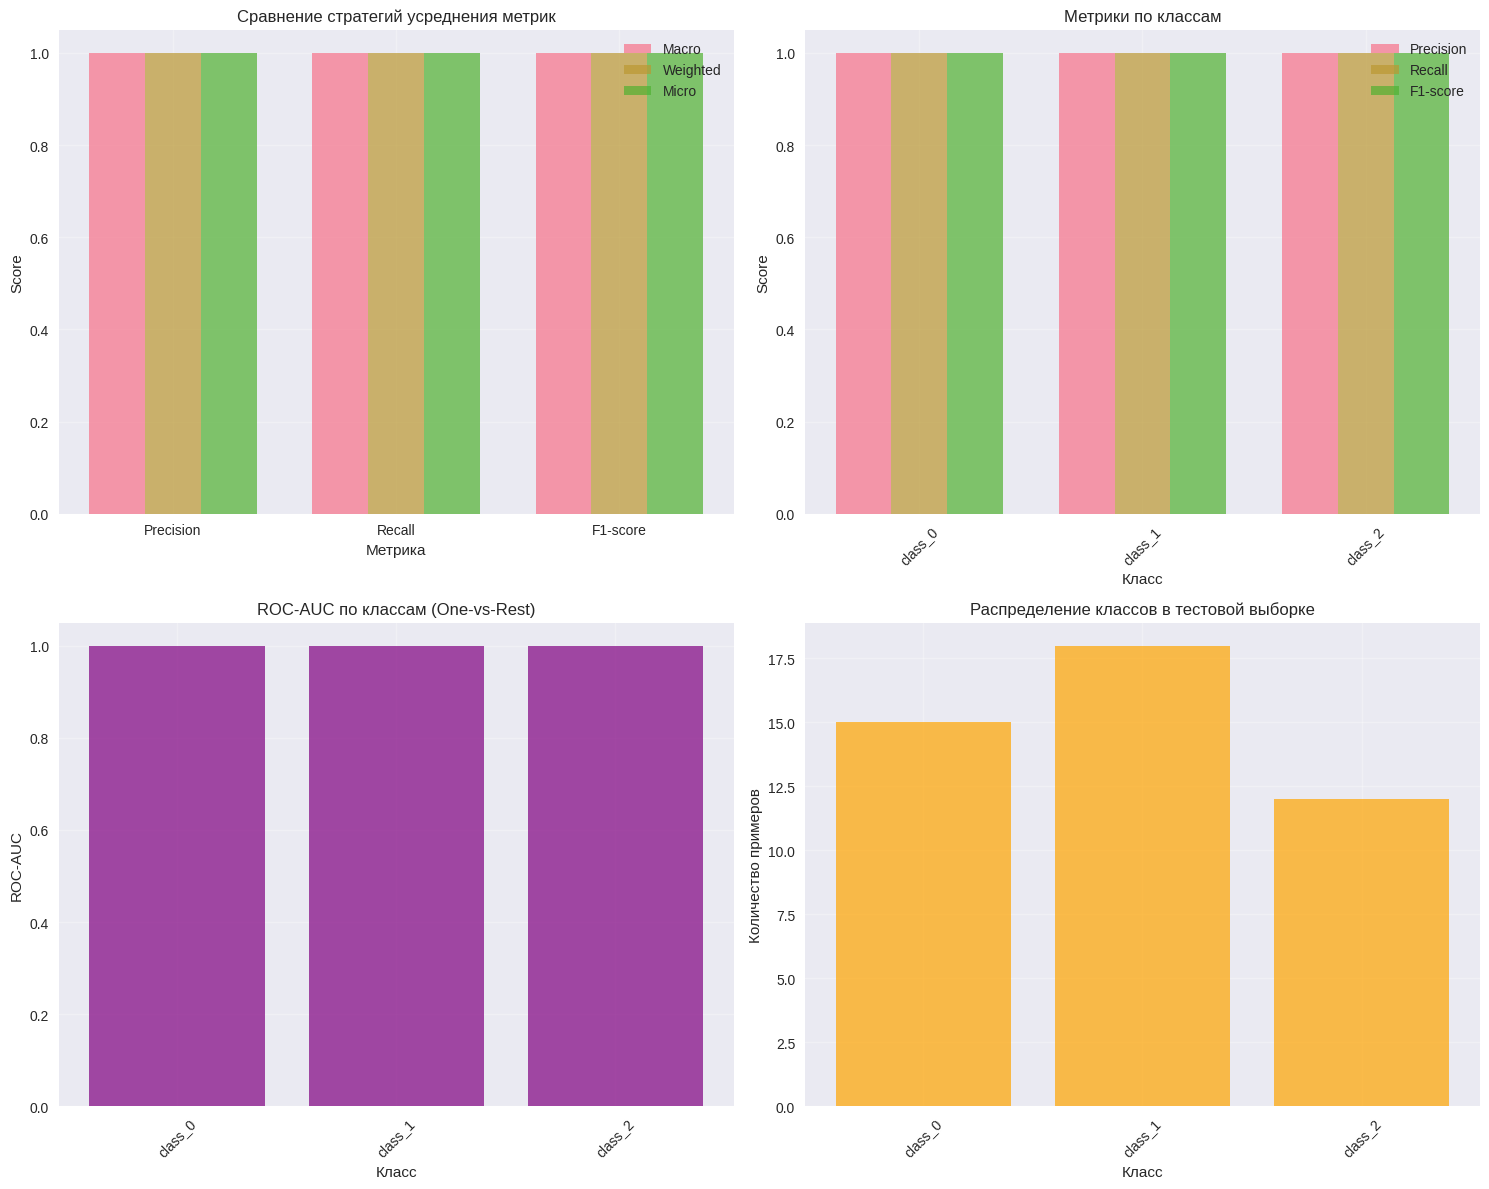

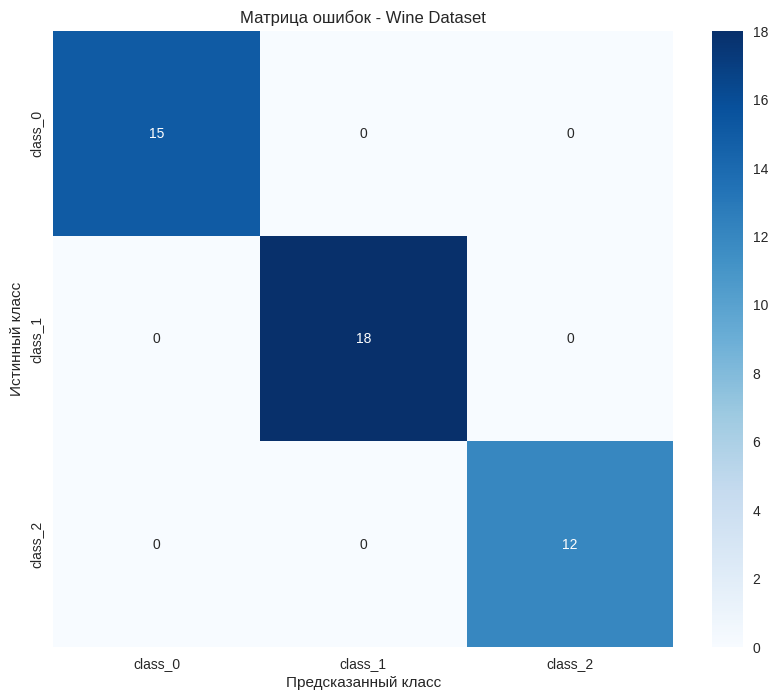

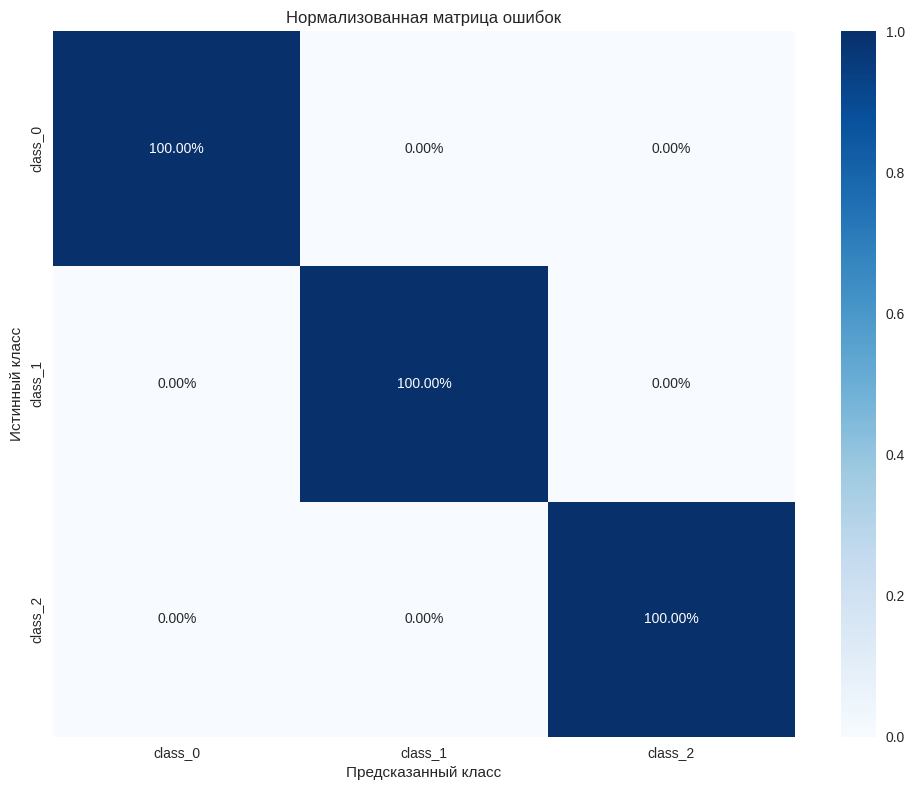


АНАЛИЗ МАТРИЦЫ ОШИБОК:
Наиболее проблемные пары классов:

АНАЛИЗ УВЕРЕННОСТИ МОДЕЛИ:


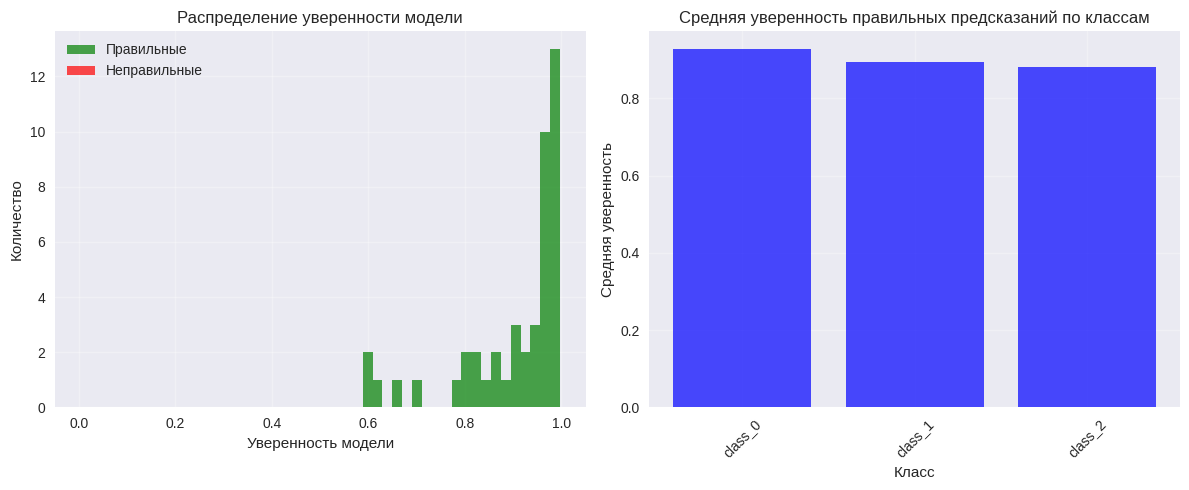

Средняя уверенность правильных предсказаний: 0.9019
Средняя уверенность неправильных предсказаний: nan
Процент предсказаний с уверенностью > 0.9: 66.67%

ДЕТАЛЬНЫЙ АНАЛИЗ ПО КЛАССАМ:

Класс: class_0
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 15

Класс: class_1
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 18

Класс: class_2
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Support: 12

АНАЛИЗ ВЛИЯНИЯ ПОРОГА КЛАССИФИКАЦИИ:


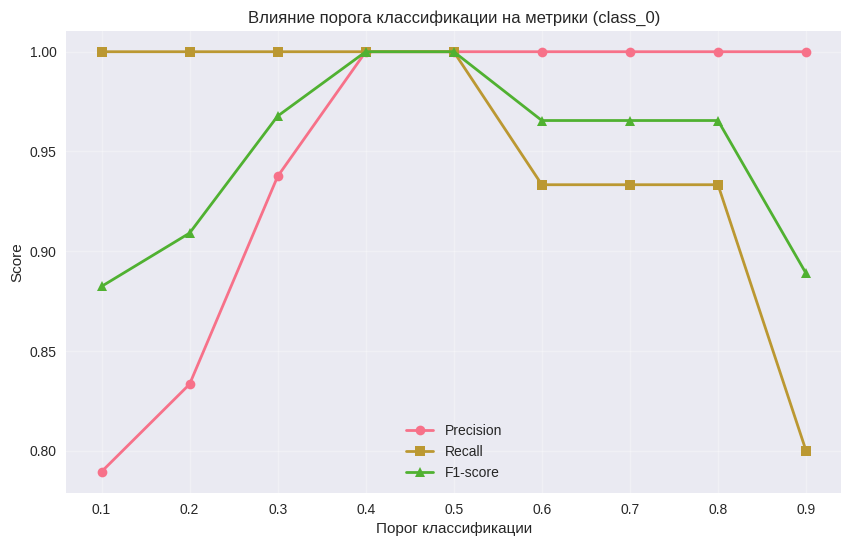


Влияние порога на класс 'class_0':
   threshold  precision  recall  f1_score
0        0.1     0.7895  1.0000    0.8824
1        0.2     0.8333  1.0000    0.9091
2        0.3     0.9375  1.0000    0.9677
3        0.4     1.0000  1.0000    1.0000
4        0.5     1.0000  1.0000    1.0000
5        0.6     1.0000  0.9333    0.9655
6        0.7     1.0000  0.9333    0.9655
7        0.8     1.0000  0.9333    0.9655
8        0.9     1.0000  0.8000    0.8889

СВОДНАЯ ТАБЛИЦА ВСЕХ МЕТРИК КАЧЕСТВА
                       Value
Accuracy              1.0000
Precision (Macro)     1.0000
Recall (Macro)        1.0000
F1-score (Macro)      1.0000
Precision (Weighted)  1.0000
Recall (Weighted)     1.0000
F1-score (Weighted)   1.0000
Log Loss              0.1122
ROC-AUC (OvR)         1.0000

ОТВЕТЫ НА КОНТРОЛЬНЫЕ ВОПРОСЫ

1. В ЧЁМ РАЗНИЦА МЕЖДУ MACRO И WEIGHTED УСРЕДНЕНИЕМ?
   - Macro: вычисляет метрику для каждого класса и усредняет (все классы равны)
   - Weighted: вычисляет средневзвешенное по количе

In [ ]:
# Задание 5. Оценка различных метрик качества логистической регрессии
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           precision_recall_fscore_support, log_loss, roc_auc_score,
                           confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Установка стиля для графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("ЗАДАНИЕ 5: ОЦЕНКА РАЗЛИЧНЫХ МЕТРИК КАЧЕСТВА ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")
print("="*70)

# Загрузка данных Wine
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

print("ИНФОРМАЦИЯ О НАБОРЕ ДАННЫХ WINE:")
print(f"Названия признаков: {wine.feature_names}")
print(f"Названия классов: {wine.target_names}")
print(f"Размерность данных: {X_wine.shape}")
print(f"Распределение классов: {np.bincount(y_wine)}")

# Создание DataFrame для анализа
wine_df = pd.DataFrame(X_wine, columns=wine.feature_names)
wine_df['target'] = y_wine
wine_df['target_name'] = [wine.target_names[i] for i in y_wine]

print("\nСтатистика по целевой переменной:")
print(wine_df['target_name'].value_counts())

# Разделение на обучающую и тестовую выборки
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine,
    test_size=0.25,
    random_state=42,
    stratify=y_wine
)

print(f"\nРАЗДЕЛЕНИЕ ДАННЫХ:")
print(f"Обучающая выборка: {X_train_w.shape}")
print(f"Тестовая выборка: {X_test_w.shape}")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train_w)}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test_w)}")

# Создание и обучение конвейера с подбором гиперпараметров
print("\nСОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ С ПОДБОРОМ ГИПЕРПАРАМЕТРОВ...")

# Создание конвейера
pipe_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=2000, random_state=42))
])

# Определение сетки гиперпараметров
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear', 'saga']
}

# Подбор гиперпараметров
grid_search = GridSearchCV(
    pipe_wine,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_w, y_train_w)

# Получение лучшей модели
best_pipe_wine = grid_search.best_estimator_

print(f"ЛУЧШИЕ ПАРАМЕТРЫ:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"Лучший F1-score на кросс-валидации: {grid_search.best_score_:.4f}")

# Предсказания лучшей модели
y_pred_wine = best_pipe_wine.predict(X_test_w)
y_pred_proba_wine = best_pipe_wine.predict_proba(X_test_w)

print(f"\nБАЗОВЫЕ МЕТРИКИ КАЧЕСТВА:")
accuracy_wine = accuracy_score(y_test_w, y_pred_wine)
print(f"Accuracy: {accuracy_wine:.4f}")

# Расчет всех метрик качества
print("\n" + "="*70)
print("ПОЛНЫЙ РАСЧЕТ МЕТРИК КАЧЕСТВА")
print("="*70)

# 1. Accuracy
accuracy = accuracy_score(y_test_w, y_pred_wine)
print(f"1. Accuracy: {accuracy:.4f}")
print("   - Доля правильных предсказаний среди всех предсказаний")

# 2. Precision, Recall, F1-score с разными стратегиями усреднения
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test_w, y_pred_wine, average='macro'
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test_w, y_pred_wine, average='weighted'
)
precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
    y_test_w, y_pred_wine, average='micro'
)

print(f"\n2. Precision, Recall, F1-score:")
print(f"   Macro averaging:")
print(f"     - Precision: {precision_macro:.4f} (среднее по классам)")
print(f"     - Recall: {recall_macro:.4f} (среднее по классам)")
print(f"     - F1-score: {f1_macro:.4f} (среднее по классам)")

print(f"\n   Weighted averaging:")
print(f"     - Precision: {precision_weighted:.4f} (взвешенное по поддержке классов)")
print(f"     - Recall: {recall_weighted:.4f} (взвешенное по поддержке классов)")
print(f"     - F1-score: {f1_weighted:.4f} (взвешенное по поддержке классов)")

print(f"\n   Micro averaging:")
print(f"     - Precision: {precision_micro:.4f} (глобальное по всем примерам)")
print(f"     - Recall: {recall_micro:.4f} (глобальное по всем примерам)")
print(f"     - F1-score: {f1_micro:.4f} (глобальное по всем примерам)")

# 3. Log Loss
log_loss_score = log_loss(y_test_w, y_pred_proba_wine)
print(f"\n3. Log Loss: {log_loss_score:.4f}")
print("   - Мера несоответствия между предсказанными вероятностями и истинными метками")
print("   - Чем меньше, тем лучше (идеал = 0)")

# 4. ROC-AUC (One-vs-Rest)
y_test_bin = label_binarize(y_test_w, classes=[0, 1, 2])
roc_auc = roc_auc_score(y_test_bin, y_pred_proba_wine, multi_class='ovr')
print(f"\n4. ROC-AUC (One-vs-Rest): {roc_auc:.4f}")
print("   - Площадь под ROC-кривой для многоклассовой классификации")
print("   - One-vs-Rest: каждый класс против всех остальных")

# 5. Метрики по классам
precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
    y_test_w, y_pred_wine, average=None
)

print(f"\n5. Метрики по классам:")
metrics_per_class = pd.DataFrame({
    'Класс': wine.target_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-score': f1_per_class,
    'Support': support_per_class
})
print(metrics_per_class.round(4))

# Визуализация сравнения метрик
plt.figure(figsize=(15, 12))

# 1. Сравнение стратегий усреднения
plt.subplot(2, 2, 1)
metrics_types = ['Precision', 'Recall', 'F1-score']
macro_values = [precision_macro, recall_macro, f1_macro]
weighted_values = [precision_weighted, recall_weighted, f1_weighted]
micro_values = [precision_micro, recall_micro, f1_micro]

x = np.arange(len(metrics_types))
width = 0.25

plt.bar(x - width, macro_values, width, label='Macro', alpha=0.7)
plt.bar(x, weighted_values, width, label='Weighted', alpha=0.7)
plt.bar(x + width, micro_values, width, label='Micro', alpha=0.7)

plt.xlabel('Метрика')
plt.ylabel('Score')
plt.title('Сравнение стратегий усреднения метрик')
plt.xticks(x, metrics_types)
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Метрики по классам
plt.subplot(2, 2, 2)
x_class = np.arange(len(wine.target_names))
width = 0.25

plt.bar(x_class - width, precision_per_class, width, label='Precision', alpha=0.7)
plt.bar(x_class, recall_per_class, width, label='Recall', alpha=0.7)
plt.bar(x_class + width, f1_per_class, width, label='F1-score', alpha=0.7)

plt.xlabel('Класс')
plt.ylabel('Score')
plt.title('Метрики по классам')
plt.xticks(x_class, wine.target_names, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 3. ROC-AUC по классам (One-vs-Rest)
plt.subplot(2, 2, 3)
roc_auc_per_class = roc_auc_score(y_test_bin, y_pred_proba_wine, average=None)
plt.bar(wine.target_names, roc_auc_per_class, alpha=0.7, color='purple')
plt.xlabel('Класс')
plt.ylabel('ROC-AUC')
plt.title('ROC-AUC по классам (One-vs-Rest)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 4. Support (количество примеров по классам)
plt.subplot(2, 2, 4)
plt.bar(wine.target_names, support_per_class, alpha=0.7, color='orange')
plt.xlabel('Класс')
plt.ylabel('Количество примеров')
plt.title('Распределение классов в тестовой выборке')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Матрица ошибок
cm_wine = confusion_matrix(y_test_w, y_pred_wine)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_wine, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title('Матрица ошибок - Wine Dataset')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# Нормализованная матрица ошибок
cm_normalized = cm_wine.astype('float') / cm_wine.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title('Нормализованная матрица ошибок')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

# Анализ наиболее проблемных пар классов
print("\nАНАЛИЗ МАТРИЦЫ ОШИБОК:")
print("Наиболее проблемные пары классов:")
for i in range(len(wine.target_names)):
    for j in range(len(wine.target_names)):
        if i != j and cm_wine[i, j] > 0:
            error_rate = cm_normalized[i, j] * 100
            print(f"  {wine.target_names[i]} → {wine.target_names[j]}: {error_rate:.1f}% ошибок")

# Анализ уверенности модели
print("\nАНАЛИЗ УВЕРЕННОСТИ МОДЕЛИ:")
confidence = np.max(y_pred_proba_wine, axis=1)
predicted_classes = np.argmax(y_pred_proba_wine, axis=1)
is_correct = (predicted_classes == y_test_w)

plt.figure(figsize=(12, 5))

# Распределение уверенности
plt.subplot(1, 2, 1)
plt.hist(confidence[is_correct], bins=20, alpha=0.7, label='Правильные', color='green')
plt.hist(confidence[~is_correct], bins=20, alpha=0.7, label='Неправильные', color='red')
plt.xlabel('Уверенность модели')
plt.ylabel('Количество')
plt.title('Распределение уверенности модели')
plt.legend()
plt.grid(True, alpha=0.3)

# Уверенность по классам
plt.subplot(1, 2, 2)
confidence_by_class = []
for class_idx in range(3):
    mask = (y_test_w == class_idx) & is_correct
    if mask.any():
        class_confidence = confidence[mask].mean()
    else:
        class_confidence = 0
    confidence_by_class.append(class_confidence)

plt.bar(wine.target_names, confidence_by_class, alpha=0.7, color='blue')
plt.xlabel('Класс')
plt.ylabel('Средняя уверенность')
plt.title('Средняя уверенность правильных предсказаний по классам')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Средняя уверенность правильных предсказаний: {confidence[is_correct].mean():.4f}")
print(f"Средняя уверенность неправильных предсказаний: {confidence[~is_correct].mean():.4f}")
print(f"Процент предсказаний с уверенностью > 0.9: {(confidence > 0.9).mean():.2%}")

# Сравнение метрик для разных классов
print("\nДЕТАЛЬНЫЙ АНАЛИЗ ПО КЛАССАМ:")
print("="*50)

for class_idx, class_name in enumerate(wine.target_names):
    # Бинаризация для текущего класса
    y_true_binary = (y_test_w == class_idx).astype(int)
    y_pred_binary = (y_pred_wine == class_idx).astype(int)

    # Метрики для текущего класса
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)

    print(f"\nКласс: {class_name}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  Support: {support_per_class[class_idx]}")

# Анализ влияния порога классификации на одном классе
print("\nАНАЛИЗ ВЛИЯНИЯ ПОРОГА КЛАССИФИКАЦИИ:")
class_idx = 0  # Анализируем первый класс
y_true_binary = (y_test_w == class_idx).astype(int)
y_proba_binary = y_pred_proba_wine[:, class_idx]

thresholds = np.arange(0.1, 1.0, 0.1)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_binary >= threshold).astype(int)
    precision = precision_score(y_true_binary, y_pred_threshold, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_threshold, zero_division=0)

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    })

threshold_df = pd.DataFrame(threshold_results)

plt.figure(figsize=(10, 6))
plt.plot(threshold_df['threshold'], threshold_df['precision'], 'o-', label='Precision', linewidth=2)
plt.plot(threshold_df['threshold'], threshold_df['recall'], 's-', label='Recall', linewidth=2)
plt.plot(threshold_df['threshold'], threshold_df['f1_score'], '^-', label='F1-score', linewidth=2)
plt.xlabel('Порог классификации')
plt.ylabel('Score')
plt.title(f'Влияние порога классификации на метрики ({wine.target_names[class_idx]})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nВлияние порога на класс '{wine.target_names[class_idx]}':")
print(threshold_df.round(4))

# Сводная таблица всех метрик
print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА ВСЕХ МЕТРИК КАЧЕСТВА")
print("="*70)

summary_metrics = {
    'Accuracy': [accuracy],
    'Precision (Macro)': [precision_macro],
    'Recall (Macro)': [recall_macro],
    'F1-score (Macro)': [f1_macro],
    'Precision (Weighted)': [precision_weighted],
    'Recall (Weighted)': [recall_weighted],
    'F1-score (Weighted)': [f1_weighted],
    'Log Loss': [log_loss_score],
    'ROC-AUC (OvR)': [roc_auc]
}

summary_df = pd.DataFrame(summary_metrics).T
summary_df.columns = ['Value']
print(summary_df.round(4))

# Ответы на контрольные вопросы
print("\n" + "="*70)
print("ОТВЕТЫ НА КОНТРОЛЬНЫЕ ВОПРОСЫ")
print("="*70)

print("""
1. В ЧЁМ РАЗНИЦА МЕЖДУ MACRO И WEIGHTED УСРЕДНЕНИЕМ?
   - Macro: вычисляет метрику для каждого класса и усредняет (все классы равны)
   - Weighted: вычисляет средневзвешенное по количеству примеров в каждом классе
   - Weighted лучше отражает качество при несбалансированных данных

2. ПОЧЕМУ ACCURACY МОЖЕТ БЫТЬ НЕИНФОРМАТИВНОЙ ПРИ НЕСБАЛАНСИРОВАННЫХ КЛАССАХ?
   Accuracy не учитывает распределение ошибок по классам. Модель может достичь
   высокой accuracy, просто предсказывая всегда самый частый класс, при этом
   полностью игнорируя редкие классы.

3. ЧТО ИЗМЕРЯЕТ LOG-LOSS И ПОЧЕМУ ОН ПОЛЕЗЕН?
   Log-loss измеряет несоответствие между предсказанными вероятностями и
   истинными метками. Он учитывает не только правильность предсказаний,
   но и уверенность модели. Штрафует за неправильные предсказания с высокой
   уверенностью сильнее, чем за предсказания с низкой уверенностью.

4. МОЖНО ЛИ ИСПОЛЬЗОВАТЬ ROC-AUC ДЛЯ ЗАДАЧИ С ТРЕМЯ КЛАССАМИ?
   Да, через стратегии One-vs-Rest (OvR) или One-vs-One (OvO). В scikit-learn
   используется OvR: вычисляется ROC-AUC для каждого класса против всех остальных,
   затем результаты усредняются.

5. КАКАЯ МЕТРИКА ЛУЧШЕ ОТРАЖАЕТ КАЧЕСТВО МОДЕЛИ: F1-SCORE ИЛИ ACCURACY?
   F1-score лучше при несбалансированных классах, так как учитывает и precision,
   и recall. Accuracy может вводить в заблуждение при неравномерном распределении
   классов. Выбор метрики зависит от задачи и стоимости ошибок.

6. ПОЧЕМУ В МНОГОКЛАССОВОЙ КЛАССИФИКАЦИИ НЕ ВСЕГДА УМЕСТНО ИСПОЛЬЗОВАТЬ ROC-AUC?
   ROC-AUC предполагает бинарную классификацию. В многоклассовом случае требуется
   усложнение через OvR/OvO, что может быть менее интерпретируемо. Также ROC-AUC
   может быть менее чувствителен к изменениям в качестве классификации редких классов.

7. КАК ПО МАТРИЦЕ ОШИБОК ОПРЕДЕЛИТЬ, С КАКИМИ КЛАССАМИ МОДЕЛЬ СПРАВЛЯЕТСЯ ХУЖЕ ВСЕГО?
   Посмотреть на внедиагональные элементы - большие значения указывают на путаницу
   между соответствующими классами. Также можно анализировать recall для каждого
   класса - низкий recall означает, что модель пропускает много примеров этого класса.

8. КОГДА ИСПОЛЬЗОВАТЬ КАЖДУЮ ИЗ МЕТРИК?
   - Accuracy: когда классы сбалансированы и все ошибки одинаково важны
   - Precision: когда ложноположительные дорого стоят (например, спам-фильтр)
   - Recall: когда ложноотрицательные дорого стоят (медицинская диагностика)
   - F1-score: когда нужен баланс между precision и recall
   - ROC-AUC: когда важна общая производительность при разных порогах
   - Log-loss: когда важны вероятностные предсказания и уверенность модели
""")

print("\nЗАКЛЮЧЕНИЕ:")
print("Каждая метрика предоставляет уникальную перспективу на качество модели.")
print("Выбор метрики должен определяться конкретной задачей и бизнес-требованиями.")
print("Идеальная модель демонстрирует высокие значения по всем метрикам.")

print("\nЗАДАНИЕ 5 УСПЕШНО ЗАВЕРШЕНО!")

Информация о наборе данных Breast Cancer:
Названия классов: ['malignant' 'benign']
Кодировка классов: 0 = malignant, 1 = benign
Размерность данных: (569, 30)
Распределение классов: [212 357]
Доля класса 'benign': 62.74%

Статистика по целевой переменной:
target_name
benign       357
malignant    212
Name: count, dtype: int64
Размер обучающей выборки: (398, 30)
Размер тестовой выборки: (171, 30)
Распределение классов в обучающей выборке: [148 250]
Распределение классов в тестовой выборке: [ 64 107]
Модель обучена успешно!
МЕТРИКИ КАЧЕСТВА ДЛЯ БИНАРНОЙ КЛАССИФИКАЦИИ
Accuracy:           0.9883
Precision:          0.9907
Recall (Sensitivity): 0.9907
Specificity:        0.9844
F1-score:           0.9907
ROC-AUC:            0.9981
Log-loss:           0.0655


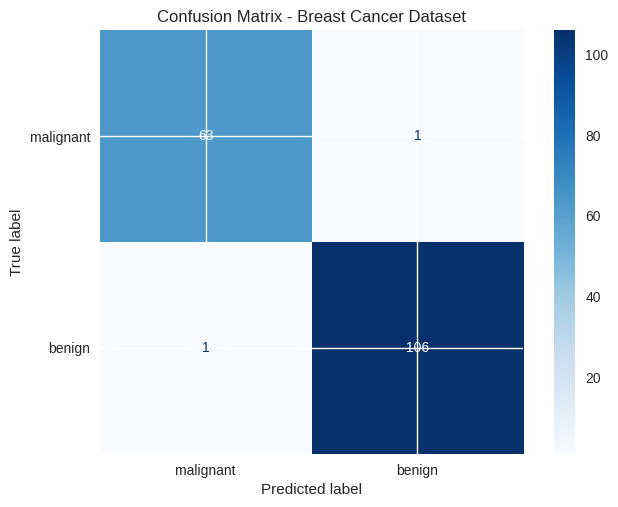


Матрица ошибок:
True Negatives (TN): 63 - правильно предсказанные 'malignant'
False Positives (FP): 1 - ложно-положительные (ошибка I рода)
False Negatives (FN): 1 - ложно-отрицательные (ошибка II рода)
True Positives (TP): 106 - правильно предсказанные 'benign'


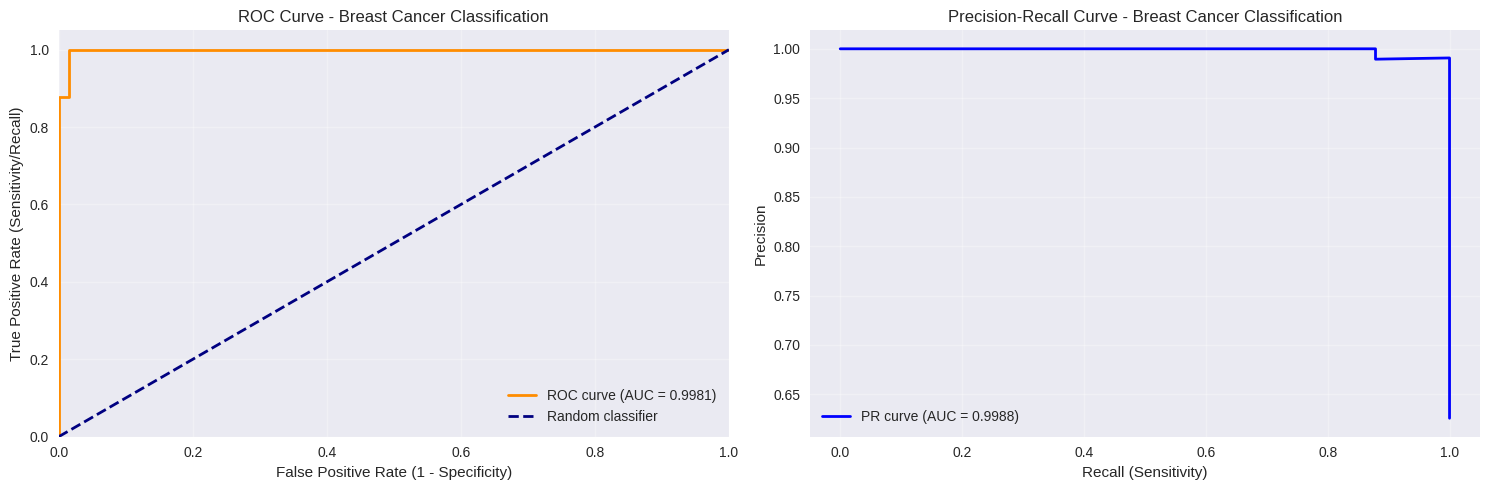

Оптимальный порог классификации (Youden's J): 0.3739
При этом пороге: Sensitivity = 1.0000, Specificity = 0.9844
Конвейер сохранен в файл 'cancer_logreg_pipeline.joblib'

--- ПРОВЕРКА ЗАГРУЗКИ МОДЕЛИ ---
Конвейер успешно загружен!
Предсказания совпадают: True
Вероятности совпадают: True
Accuracy загруженной модели: 0.9883

--- ТЕСТИРОВАНИЕ НА ОТДЕЛЬНЫХ ПРИМЕРАХ ---
Пример 1:
  Истинный класс: malignant (0)
  Предсказанный класс: malignant (0)
  Вероятности: [malignant=0.9679, benign=0.0321]

Случайный пример (индекс 149):
  Истинный класс: benign (1)
  Предсказанный класс: benign (1)
  Вероятности: [malignant=0.0000, benign=1.0000]

--- ТЕСТИРОВАНИЕ НА СИНТЕТИЧЕСКОМ ПРИМЕРЕ ---
Синтетический пример (на основе средних значений):
  Предсказанный класс: benign
  Вероятности: [malignant=0.4931, benign=0.5069]

ТОП-10 ВАЖНЕЙШИХ ПРИЗНАКОВ:
                 feature  coefficient  abs_coefficient
21         worst texture      -1.2263           1.2263
27  worst concave points      -0.9968       

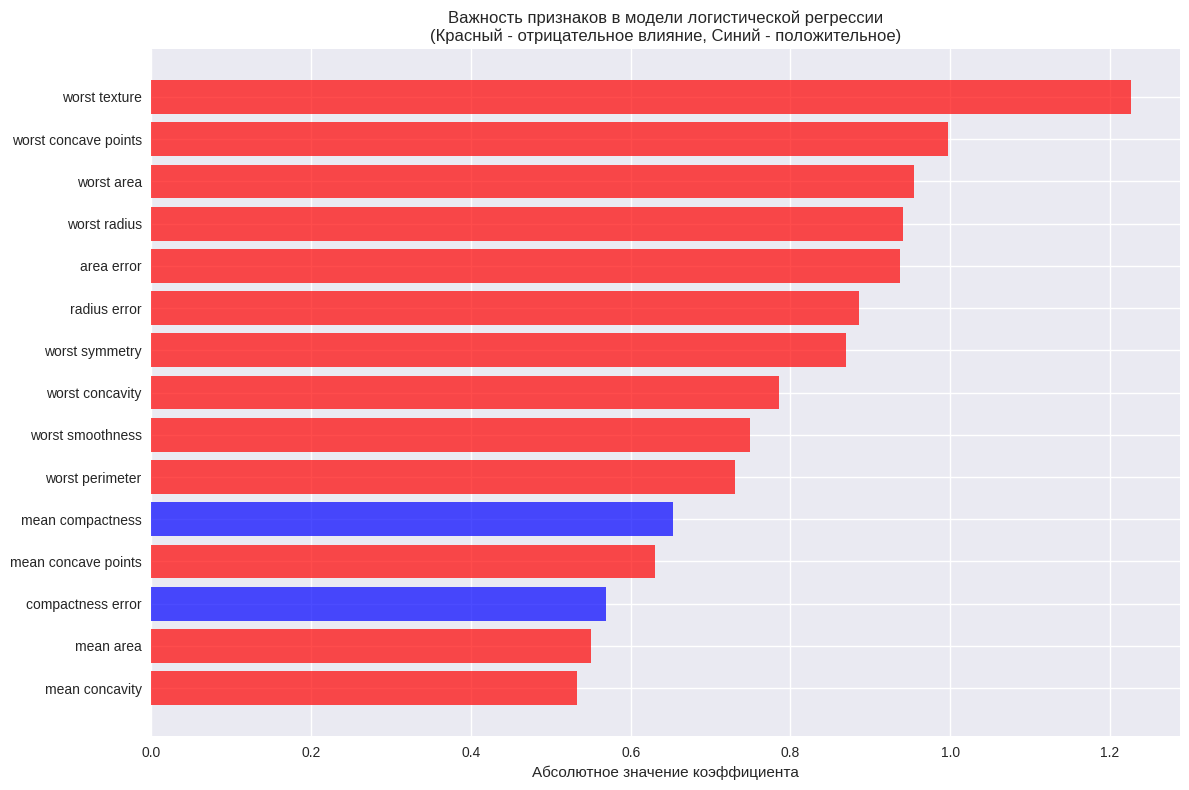


Ответы на вопросы (Задание 6):

1. Какая метрика наиболее важна в медицинской диагностике рака?
   RECALL (чувствительность) наиболее важна, так как мы не хотим пропустить
   ни одного случая рака (минимизировать ложно-отрицательные результаты).

2. Что означает высокий recall для класса «злокачественная опухоль»?
   Высокий recall означает, что модель правильно идентифицирует большинство
   реальных случаев рака, минимизируя пропущенные диагнозы.

3. Что означает низкая specificity? Почему она важна?
   Низкая specificity означает много ложно-положительных результатов.
   Это важно, потому что приводит к ненужным дополнительным обследованиям
   и психологическому стрессу пациентов.

4. Почему accuracy может вводить в заблуждение?
   При несбалансированных классах accuracy может быть высокой, даже если
   модель плохо предсказывает редкий класс (в данном случае - злокачественные опухоли).

5. Почему в задаче диагностики рака recall важнее accuracy?
   Пропуск рака (ложно-отрицательный

In [ ]:
# Импорт дополнительных библиотек для бинарной классификации
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных о раке груди
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# Важно: понимание целевой переменной
print("Информация о наборе данных Breast Cancer:")
print(f"Названия классов: {cancer.target_names}")
print(f"Кодировка классов: 0 = {cancer.target_names[0]}, 1 = {cancer.target_names[1]}")
print(f"Размерность данных: {X_cancer.shape}")
print(f"Распределение классов: {np.bincount(y_cancer)}")
print(f"Доля класса '{cancer.target_names[1]}': {np.mean(y_cancer):.2%}")

# Создание DataFrame для анализа
cancer_df = pd.DataFrame(X_cancer, columns=cancer.feature_names)
cancer_df['target'] = y_cancer
cancer_df['target_name'] = [cancer.target_names[i] for i in y_cancer]

print("\nСтатистика по целевой переменной:")
print(cancer_df['target_name'].value_counts())
# Разделение на обучающую и тестовую выборки
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer,
    test_size=0.3,
    random_state=42,
    stratify=y_cancer  # Важно при несбалансированных данных
)

print(f"Размер обучающей выборки: {X_train_c.shape}")
print(f"Размер тестовой выборки: {X_test_c.shape}")
print(f"Распределение классов в обучающей выборке: {np.bincount(y_train_c)}")
print(f"Распределение классов в тестовой выборке: {np.bincount(y_test_c)}")

# Создание конвейера
pipe_cancer = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Обучение модели
pipe_cancer.fit(X_train_c, y_train_c)

# Предсказания
y_pred_c = pipe_cancer.predict(X_test_c)
y_pred_proba_c = pipe_cancer.predict_proba(X_test_c)[:, 1]  # Вероятность положительного класса

print("Модель обучена успешно!")
# Расчет основных метрик
accuracy_c = accuracy_score(y_test_c, y_pred_c)
precision_c = precision_score(y_test_c, y_pred_c)
recall_c = recall_score(y_test_c, y_pred_c)
f1_c = f1_score(y_test_c, y_pred_c)

# Расчет specificity (специфичности)
tn, fp, fn, tp = confusion_matrix(y_test_c, y_pred_c).ravel()
specificity_c = tn / (tn + fp)  # True Negative Rate

# ROC-AUC
roc_auc_c = roc_auc_score(y_test_c, y_pred_proba_c)

# Log-loss
log_loss_c = log_loss(y_test_c, y_pred_proba_c)

print("МЕТРИКИ КАЧЕСТВА ДЛЯ БИНАРНОЙ КЛАССИФИКАЦИИ")
print("=" * 60)
print(f"Accuracy:           {accuracy_c:.4f}")
print(f"Precision:          {precision_c:.4f}")  # Точность для положительного класса
print(f"Recall (Sensitivity): {recall_c:.4f}")   # Чувствительность
print(f"Specificity:        {specificity_c:.4f}") # Специфичность
print(f"F1-score:           {f1_c:.4f}")
print(f"ROC-AUC:            {roc_auc_c:.4f}")
print(f"Log-loss:           {log_loss_c:.4f}")

# Матрица ошибок
cm_cancer = confusion_matrix(y_test_c, y_pred_c)
disp_cancer = ConfusionMatrixDisplay(confusion_matrix=cm_cancer,
                                   display_labels=cancer.target_names)
disp_cancer.plot(cmap='Blues')
plt.title('Confusion Matrix - Breast Cancer Dataset')
plt.show()

print(f"\nМатрица ошибок:")
print(f"True Negatives (TN): {tn} - правильно предсказанные '{cancer.target_names[0]}'")
print(f"False Positives (FP): {fp} - ложно-положительные (ошибка I рода)")
print(f"False Negatives (FN): {fn} - ложно-отрицательные (ошибка II рода)")
print(f"True Positives (TP): {tp} - правильно предсказанные '{cancer.target_names[1]}'")
# ROC-кривая
fpr, tpr, thresholds_roc = roc_curve(y_test_c, y_pred_proba_c)
roc_auc = auc(fpr, tpr)

# Precision-Recall кривая
precision, recall, thresholds_pr = precision_recall_curve(y_test_c, y_pred_proba_c)
pr_auc = auc(recall, precision)

# Построение графиков
plt.figure(figsize=(15, 5))

# ROC-кривая
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('ROC Curve - Breast Cancer Classification')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Precision-Recall кривая
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Breast Cancer Classification')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Нахождение оптимального порога по Youden's J statistic
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds_roc[optimal_idx]

print(f"Оптимальный порог классификации (Youden's J): {optimal_threshold:.4f}")
print(f"При этом пороге: Sensitivity = {tpr[optimal_idx]:.4f}, Specificity = {1-fpr[optimal_idx]:.4f}")
# Сохранение конвейера
joblib.dump(pipe_cancer, 'cancer_logreg_pipeline.joblib')
print("Конвейер сохранен в файл 'cancer_logreg_pipeline.joblib'")

# Проверка загрузки (имитация нового сеанса)
print("\n--- ПРОВЕРКА ЗАГРУЗКИ МОДЕЛИ ---")

# Удаляем исходный конвейер из памяти (имитируем новый сеанс)
del pipe_cancer

# Загрузка конвейера
loaded_pipeline = joblib.load('cancer_logreg_pipeline.joblib')
print("Конвейер успешно загружен!")

# Предсказания с загруженной моделью
y_pred_loaded = loaded_pipeline.predict(X_test_c)
y_proba_loaded = loaded_pipeline.predict_proba(X_test_c)[:, 1]

# Проверка совпадения предсказаний
predictions_match = np.array_equal(y_pred_c, y_pred_loaded)
probabilities_match = np.allclose(y_pred_proba_c, y_proba_loaded)

print(f"Предсказания совпадают: {predictions_match}")
print(f"Вероятности совпадают: {probabilities_match}")

# Расчет метрик для загруженной модели
accuracy_loaded = accuracy_score(y_test_c, y_pred_loaded)
print(f"Accuracy загруженной модели: {accuracy_loaded:.4f}")
# Тестирование на отдельных примерах из тестовой выборки
print("\n--- ТЕСТИРОВАНИЕ НА ОТДЕЛЬНЫХ ПРИМЕРАХ ---")

# Преобразование в DataFrame для удобства (если нужно)
X_test_df = pd.DataFrame(X_test_c, columns=cancer.feature_names)

class_0 = cancer.target_names[0]  # 'malignant'
class_1 = cancer.target_names[1]  # 'benign'
# Тестирование на первом примере из тестовой выборки
sample_1 = X_test_c[0:1]  # Берем первую строку
true_label_1 = y_test_c[0]

prediction_1 = loaded_pipeline.predict(sample_1)
probability_1 = loaded_pipeline.predict_proba(sample_1)

print(f"Пример 1:")
print(f"  Истинный класс: {cancer.target_names[true_label_1]} ({true_label_1})")
print(f"  Предсказанный класс: {cancer.target_names[prediction_1[0]]} ({prediction_1[0]})")
print(f"  Вероятности: [{class_0}={probability_1[0][0]:.4f}, {class_1}={probability_1[0][1]:.4f}]")

# Тестирование на случайном примере
random_idx = np.random.randint(0, len(X_test_c))
sample_random = X_test_c[random_idx:random_idx+1]
true_label_random = y_test_c[random_idx]

prediction_random = loaded_pipeline.predict(sample_random)
probability_random = loaded_pipeline.predict_proba(sample_random)

print(f"\nСлучайный пример (индекс {random_idx}):")
print(f"  Истинный класс: {cancer.target_names[true_label_random]} ({true_label_random})")
print(f"  Предсказанный класс: {cancer.target_names[prediction_random[0]]} ({prediction_random[0]})")
print(f"  Вероятности: [{class_0}={probability_random[0][0]:.4f}, {class_1}={probability_random[0][1]:.4f}]")

# Создание синтетического примера для тестирования
print(f"\n--- ТЕСТИРОВАНИЕ НА СИНТЕТИЧЕСКОМ ПРИМЕРЕ ---")

# Берем средние значения признаков и немного их варьируем
mean_features = np.mean(X_train_c, axis=0)
std_features = np.std(X_train_c, axis=0)

# Создаем синтетический пример на основе статистик
synthetic_sample = mean_features.reshape(1, -1)
# Добавляем небольшой шум
synthetic_sample += np.random.normal(0, 0.1 * std_features, size=synthetic_sample.shape)

synthetic_pred = loaded_pipeline.predict(synthetic_sample)
synthetic_proba = loaded_pipeline.predict_proba(synthetic_sample)

print(f"Синтетический пример (на основе средних значений):")
print(f"  Предсказанный класс: {cancer.target_names[synthetic_pred[0]]}")
print(f"  Вероятности: [{class_0}={synthetic_proba[0][0]:.4f}, {class_1}={synthetic_proba[0][1]:.4f}]")
# Анализ важности признаков в бинарной классификации
logreg_model = loaded_pipeline.named_steps['logreg']
feature_importance = pd.DataFrame({
    'feature': cancer.feature_names,
    'coefficient': logreg_model.coef_[0],
    'abs_coefficient': np.abs(logreg_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\nТОП-10 ВАЖНЕЙШИХ ПРИЗНАКОВ:")
print(feature_importance.head(10).round(4))

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
colors = ['red' if coef < 0 else 'blue' for coef in top_features['coefficient']]

plt.barh(top_features['feature'], top_features['abs_coefficient'], color=colors, alpha=0.7)
plt.xlabel('Абсолютное значение коэффициента')
plt.title('Важность признаков в модели логистической регрессии\n(Красный - отрицательное влияние, Синий - положительное)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("""
Ответы на вопросы (Задание 6):

1. Какая метрика наиболее важна в медицинской диагностике рака?
   RECALL (чувствительность) наиболее важна, так как мы не хотим пропустить
   ни одного случая рака (минимизировать ложно-отрицательные результаты).

2. Что означает высокий recall для класса «злокачественная опухоль»?
   Высокий recall означает, что модель правильно идентифицирует большинство
   реальных случаев рака, минимизируя пропущенные диагнозы.

3. Что означает низкая specificity? Почему она важна?
   Низкая specificity означает много ложно-положительных результатов.
   Это важно, потому что приводит к ненужным дополнительным обследованиям
   и психологическому стрессу пациентов.

4. Почему accuracy может вводить в заблуждение?
   При несбалансированных классах accuracy может быть высокой, даже если
   модель плохо предсказывает редкий класс (в данном случае - злокачественные опухоли).

5. Почему в задаче диагностики рака recall важнее accuracy?
   Пропуск рака (ложно-отрицательный) гораздо опаснее, чем ложная тревога.

6. Как вычисляется specificity?
   Specificity = TN / (TN + FP) = Истинно-отрицательные / Все отрицательные

7. Почему log-loss учитывает не только правильность, но и уверенность?
   Log-loss штрафует модель за неправильные предсказания с высокой уверенностью
   сильнее, чем за неправильные предсказания с низкой уверенностью.

8. Какое значение ROC-AUC говорит о том, что модель «лучше случайного»?
   ROC-AUC > 0.5 указывает на то, что модель лучше случайного угадывания.

9. Почему важно сохранять весь конвейер, а не только модель?
   Чтобы новые данные проходили ту же предобработку (масштабирование),
   что и обучающие данные.

10. Что произойдёт без предварительного масштабирования?
    Модель может работать некорректно, так как она обучена на масштабированных данных.

11. Можно ли использовать конвейер для данных от другого медицинского центра?
    Технически - да, но нужна валидация, так как могут быть различия в методах
    измерения и распределении данных.
""")
# Анализ с медицинской точки зрения
print("\nМЕДИЦИНСКАЯ ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")
print("=" * 50)

# Расчет дополнительных медицинских метрик
false_negative_rate = fn / (fn + tp)  # Пропущенные случаи рака
false_positive_rate = fp / (fp + tn)  # Ложные тревоги
negative_predictive_value = tn / (tn + fn)  # Вероятность, что отрицательный диагноз правильный

print(f"Ложно-отрицательная ставка (пропущенные раки): {false_negative_rate:.2%}")
print(f"Ложно-положительная ставка (ложные тревоги): {false_positive_rate:.2%}")
print(f"Negative Predictive Value: {negative_predictive_value:.2%}")

# Анализ влияния порога классификации
print(f"\nАНАЛИЗ ВЛИЯНИЯ ПОРОГА КЛАССИФИКАЦИИ:")
print(f"Текущий порог: 0.5")
print(f"При пороге {optimal_threshold:.3f}:")
print(f"  - Sensitivity: {tpr[optimal_idx]:.2%}")
print(f"  - Specificity: {1-fpr[optimal_idx]:.2%}")

# Рекомендации для разных сценариев
print(f"\nРЕКОМЕНДАЦИИ:")
print("1. Для скрининга (минимизация пропущенных случаев):")
print("   - Использовать более низкий порог (например, 0.3)")
print("   - Увеличить recall, даже за счет specificity")

print("2. Для подтверждающей диагностики:")
print("   - Использовать более высокий порог (например, 0.7)")
print("   - Увеличить precision, минимизируя ложные тревоги")

print("3. Для балансированного подхода:")
print(f"   - Использовать оптимальный порог ({optimal_threshold:.3f})")

ДАННЫЕ ДЛЯ СРАВНЕНИЯ МОДЕЛЕЙ:
Обучающая выборка: (124, 13)
Тестовая выборка: (54, 13)
Классы: ['class_0' 'class_1' 'class_2']
Распределение: [41 50 33]
КОНФИГУРАЦИЯ МОДЕЛЕЙ ДЛЯ СРАВНЕНИЯ:
Logistic Regression: 3 наборов параметров
kNN: 3 наборов параметров
SVM: 3 наборов параметров
Decision Tree: 3 наборов параметров
Random Forest: 3 наборов параметров
ЗАПУСК СРАВНЕНИЯ МОДЕЛЕЙ...

Обучение Logistic Regression...
✓ Logistic Regression завершено за 2.43 сек
  Лучшие параметры: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  CV F1: 0.9838, Test F1: 0.9815

Обучение kNN...
✓ kNN завершено за 0.61 сек
  Лучшие параметры: {'clf__metric': 'manhattan', 'clf__n_neighbors': 5, 'clf__weights': 'uniform'}
  CV F1: 0.9750, Test F1: 0.9816

Обучение SVM...
✓ SVM завершено за 0.70 сек
  Лучшие параметры: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
  CV F1: 0.9921, Test F1: 0.9814

Обучение Decision Tree...
✓ Decision Tree завершено за 0.68 сек
  Лучшие параметры: {'clf__cr

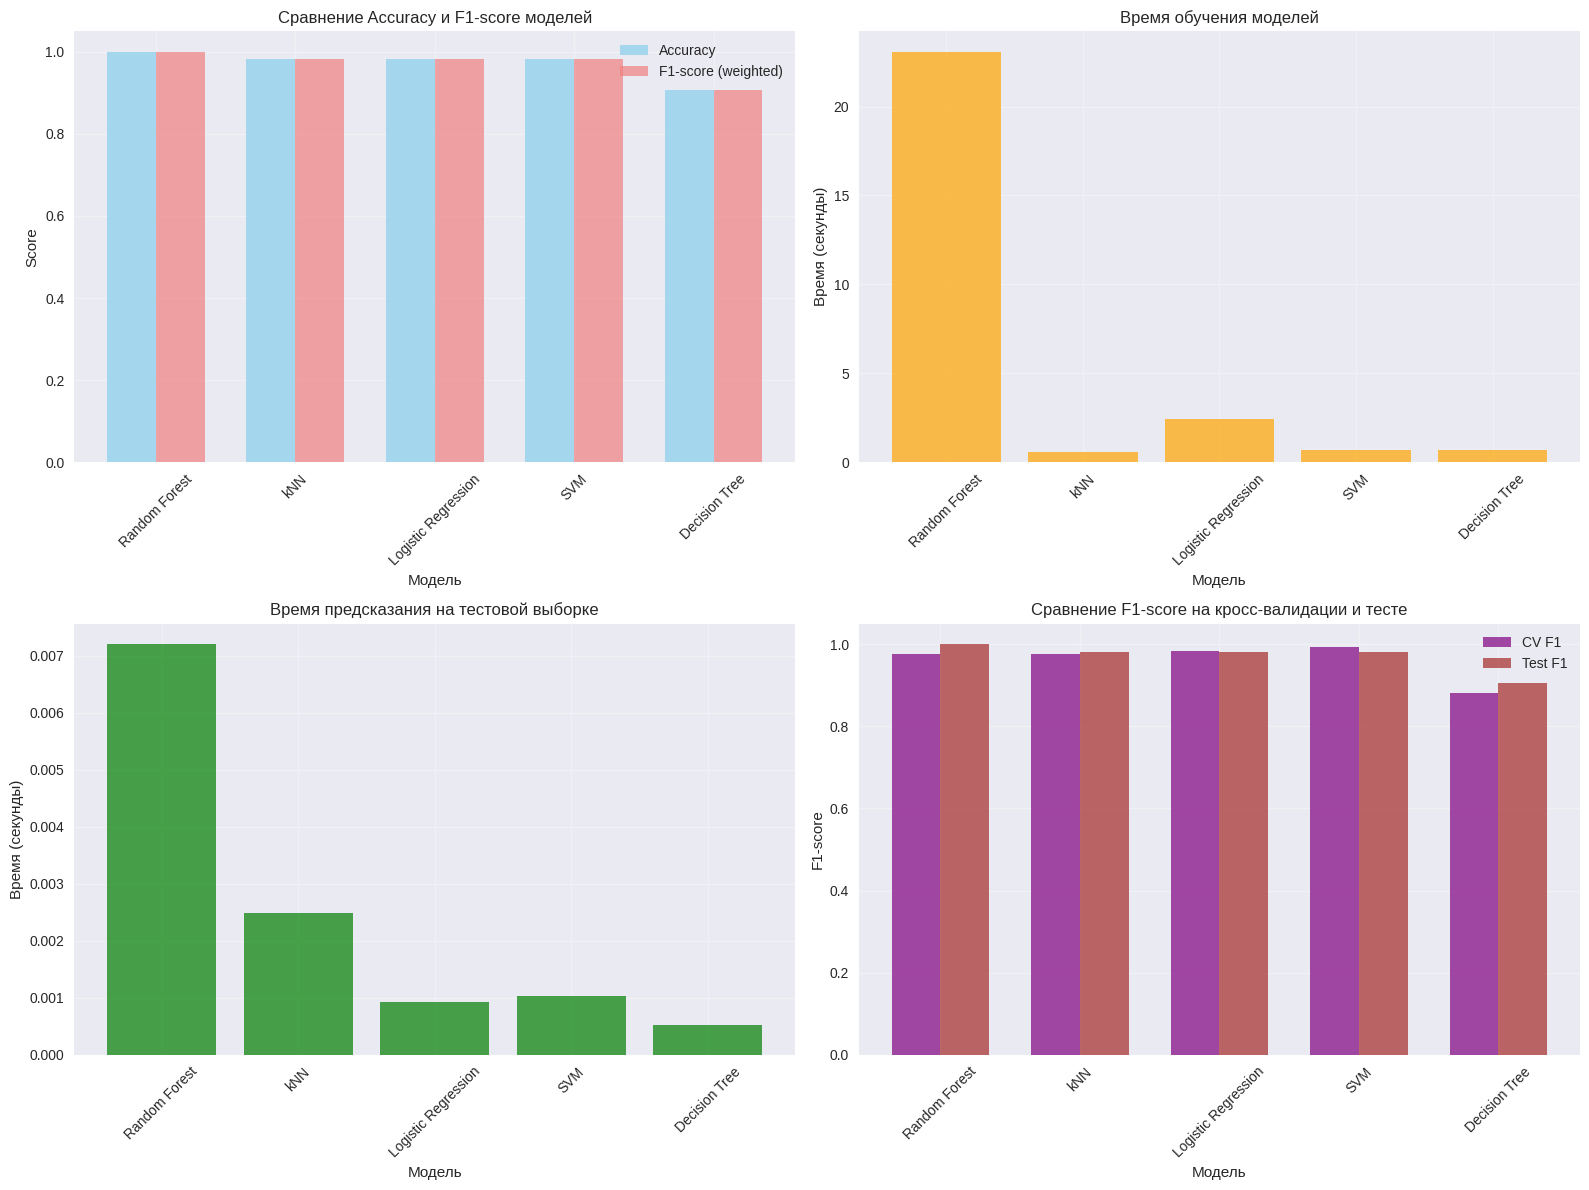

ЛУЧШАЯ МОДЕЛЬ: Random Forest
Параметры: {'clf__max_depth': 3, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Test F1-score: 1.0000


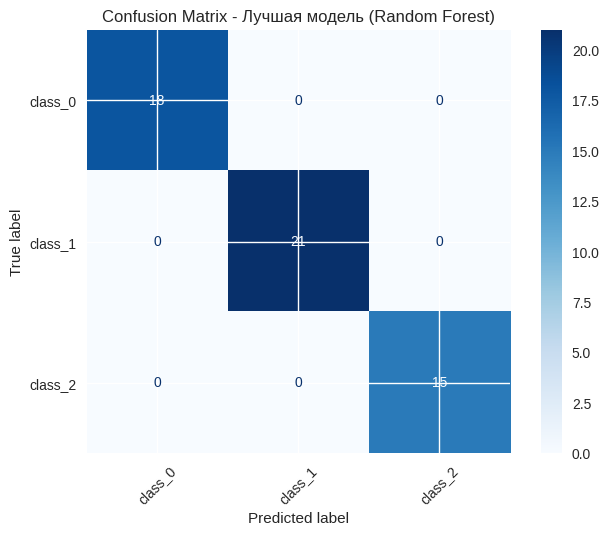


Classification Report для Random Forest:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



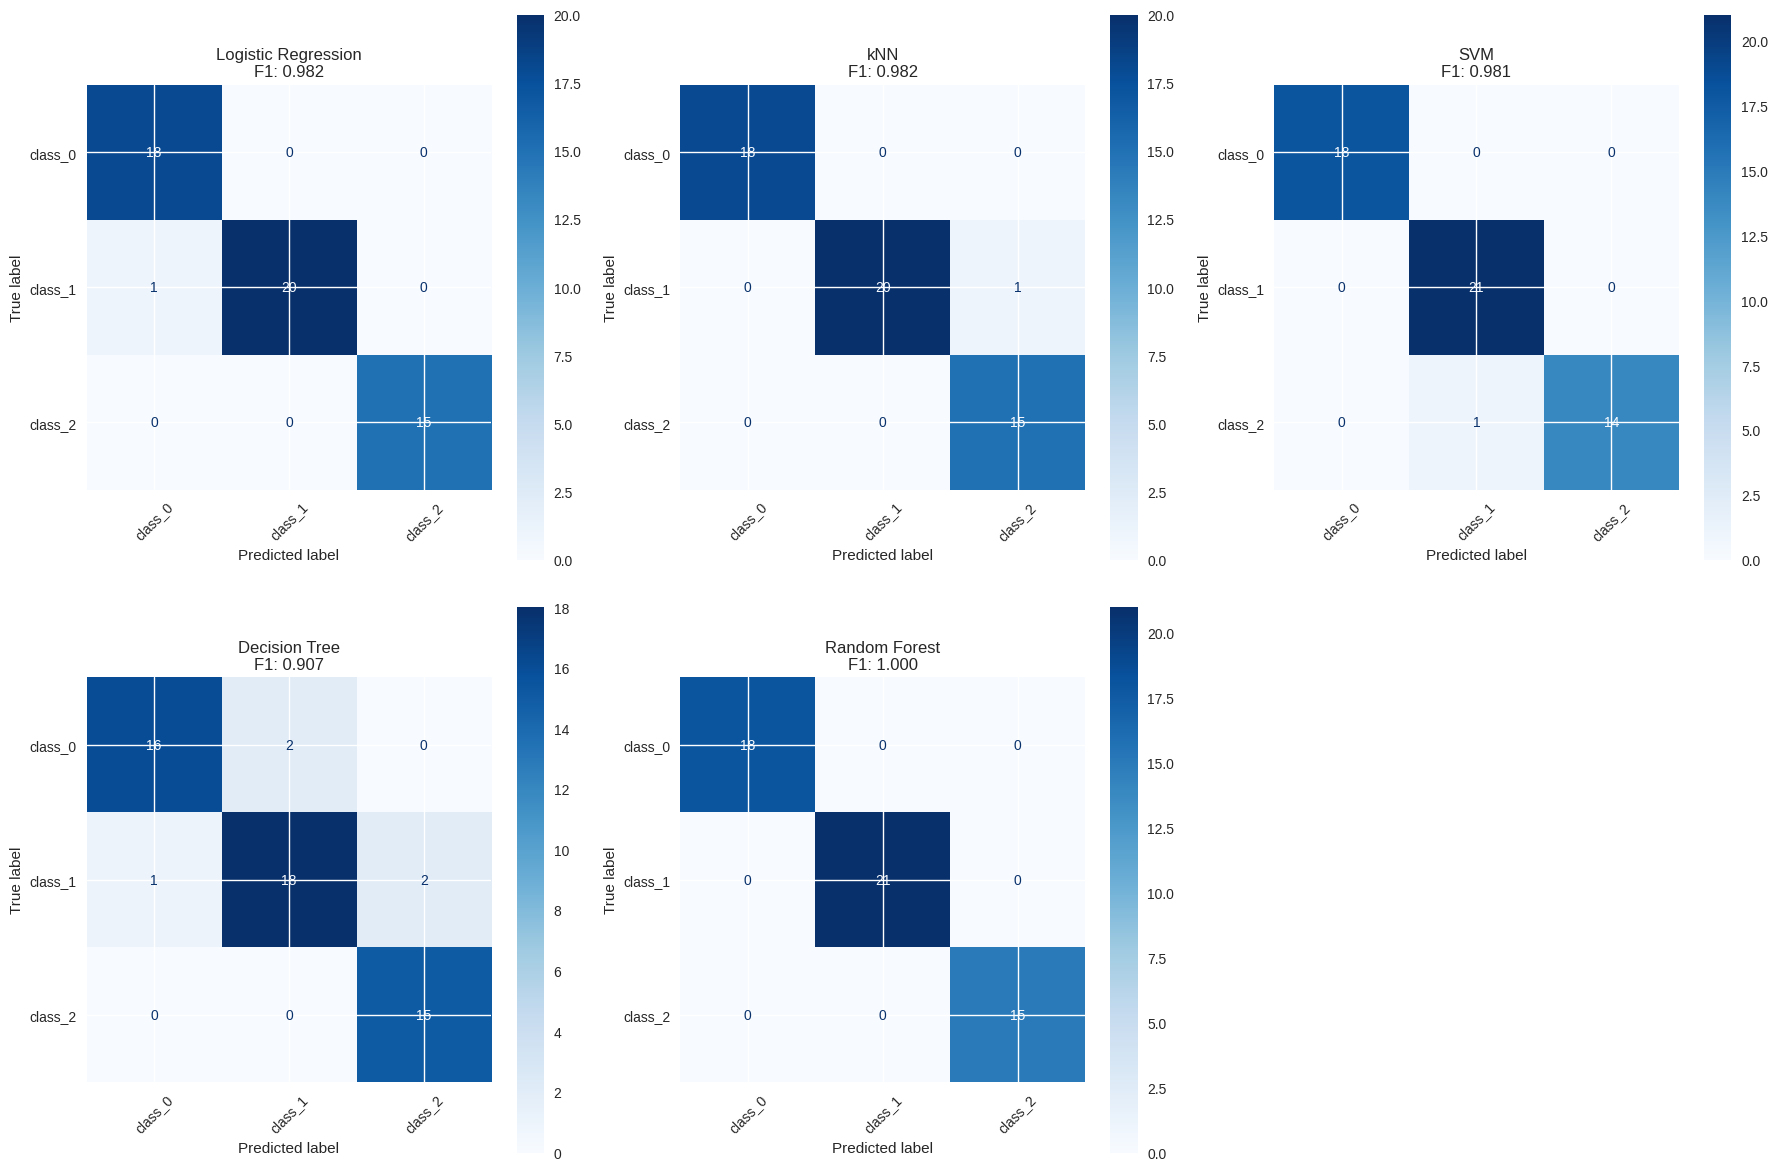


Ответы на вопросы (Задание 7):

1. Почему kNN чувствителен к масштабу признаков, а дерево решений — нет?
   kNN использует расстояния между точками, поэтому масштаб признаков напрямую влияет на расстояния.
   Деревья решений разделяют данные по пороговым значениям, которые не зависят от масштаба.

2. Как выбор ядра (kernel) влияет на качество SVM?
   - Linear: для линейно разделимых данных
   - RBF: для сложных нелинейных границ
   - Poly: для полиномиальных зависимостей
   Выбор ядра определяет способность модели аппроксимировать сложные границы.

3. Почему для дерева решений не требуется масштабирование?
   Деревья решений работают с порядковыми отношениями "больше/меньше", 
   а не с абсолютными значениями признаков.

4. Какие методы являются линейными, а какие — нелинейными?
   Линейные: Logistic Regression, SVM с linear kernel
   Нелинейные: kNN, SVM с rbf/poly kernel, Decision Tree, Random Forest

5. Какие методы лучше интерпретируются?
   Logistic Regression и Decision Tree наи

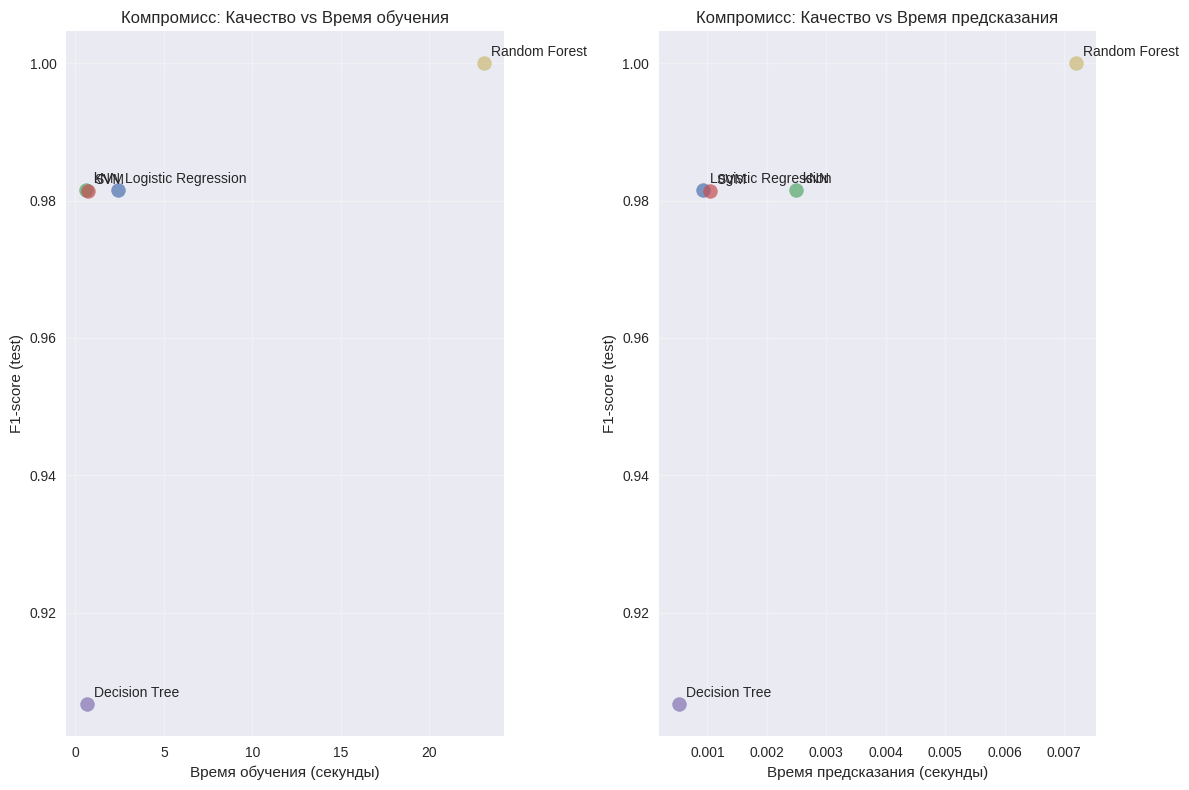


ВЫВОДЫ И РЕКОМЕНДАЦИИ:
Лучшая по качеству: Random Forest (F1: 1.0000)
Самая быстрая в обучении: kNN (0.61 сек)
Самая быстрая в предсказании: Decision Tree (0.0005 сек)

Рекомендации по выбору модели:
1. Для production с высокими требованиями к качеству: Лучшая по F1-score
2. Для real-time приложений: Самая быстрая в предсказании
3. Для частого переобучения: Самая быстрая в обучении
4. Для интерпретируемости: Logistic Regression или Decision Tree


In [ ]:
# Импорт дополнительных классификаторов
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import time

# Загрузка данных Wine для сравнения
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

# Разделение данных
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine,
    test_size=0.3,
    random_state=42,
    stratify=y_wine
)

print("ДАННЫЕ ДЛЯ СРАВНЕНИЯ МОДЕЛЕЙ:")
print(f"Обучающая выборка: {X_train_w.shape}")
print(f"Тестовая выборка: {X_test_w.shape}")
print(f"Классы: {wine.target_names}")
print(f"Распределение: {np.bincount(y_train_w)}")

# Словарь моделей с параметрами для GridSearch
models = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10, 100],
            'clf__penalty': ['l2'],
            'clf__solver': ['lbfgs', 'liblinear']
        }
    },
    'kNN': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'params': {
            'clf__n_neighbors': [3, 5, 7, 9, 11],
            'clf__weights': ['uniform', 'distance'],
            'clf__metric': ['euclidean', 'manhattan']
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(probability=True, random_state=42))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['linear', 'rbf', 'poly'],
            'clf__gamma': ['scale', 'auto']
        }
    },
    'Decision Tree': {
        'pipeline': Pipeline([
            ('clf', DecisionTreeClassifier(random_state=42))  # Без масштабирования для дерева
        ]),
        'params': {
            'clf__max_depth': [3, 5, 7, 10, None],
            'clf__min_samples_split': [2, 5, 10],
            'clf__criterion': ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('clf', RandomForestClassifier(random_state=42))  # Без масштабирования для леса
        ]),
        'params': {
            'clf__n_estimators': [50, 100, 200],
            'clf__max_depth': [3, 5, 7, None],
            'clf__min_samples_split': [2, 5]
        }
    }
}

print("КОНФИГУРАЦИЯ МОДЕЛЕЙ ДЛЯ СРАВНЕНИЯ:")
for name, config in models.items():
    print(f"{name}: {len(config['params'])} наборов параметров")

# Сравнение моделей
results = []
best_models = {}

print("ЗАПУСК СРАВНЕНИЯ МОДЕЛЕЙ...")
print("=" * 60)

for name, config in models.items():
    print(f"\nОбучение {name}...")
    start_time = time.time()

    # GridSearchCV
    grid = GridSearchCV(
        config['pipeline'],
        config['params'],
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train_w, y_train_w)
    training_time = time.time() - start_time

    # Предсказания на тестовой выборке
    start_pred_time = time.time()
    y_pred = grid.best_estimator_.predict(X_test_w)
    prediction_time = time.time() - start_pred_time

    # Расчет метрик
    accuracy = accuracy_score(y_test_w, y_pred)
    f1 = f1_score(y_test_w, y_pred, average='weighted')
    cv_score = grid.best_score_

    # Сохранение результатов
    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'CV F1 (weighted)': cv_score,
        'Test Accuracy': accuracy,
        'Test F1 (weighted)': f1,
        'Training Time (s)': training_time,
        'Prediction Time (s)': prediction_time
    })

    best_models[name] = grid.best_estimator_

    print(f"✓ {name} завершено за {training_time:.2f} сек")
    print(f"  Лучшие параметры: {grid.best_params_}")
    print(f"  CV F1: {cv_score:.4f}, Test F1: {f1:.4f}")

# Создание DataFrame с результатами
results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ ЗАВЕРШЕНО!")

# Сортировка результатов по F1-score
results_df_sorted = results_df.sort_values('Test F1 (weighted)', ascending=False)

print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ (отсортировано по F1-score):")
print(results_df_sorted[['Model', 'Test Accuracy', 'Test F1 (weighted)',
                        'Training Time (s)', 'Prediction Time (s)']].round(4))

# Визуализация сравнения моделей
plt.figure(figsize=(16, 12))

# 1. Сравнение точности и F1-score
plt.subplot(2, 2, 1)
x_pos = np.arange(len(results_df_sorted))
width = 0.35

plt.bar(x_pos - width/2, results_df_sorted['Test Accuracy'], width,
        label='Accuracy', alpha=0.7, color='skyblue')
plt.bar(x_pos + width/2, results_df_sorted['Test F1 (weighted)'], width,
        label='F1-score (weighted)', alpha=0.7, color='lightcoral')

plt.xlabel('Модель')
plt.ylabel('Score')
plt.title('Сравнение Accuracy и F1-score моделей')
plt.xticks(x_pos, results_df_sorted['Model'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Время обучения
plt.subplot(2, 2, 2)
plt.bar(results_df_sorted['Model'], results_df_sorted['Training Time (s)'],
        alpha=0.7, color='orange')
plt.xlabel('Модель')
plt.ylabel('Время (секунды)')
plt.title('Время обучения моделей')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 3. Время предсказания
plt.subplot(2, 2, 3)
plt.bar(results_df_sorted['Model'], results_df_sorted['Prediction Time (s)'],
        alpha=0.7, color='green')
plt.xlabel('Модель')
plt.ylabel('Время (секунды)')
plt.title('Время предсказания на тестовой выборке')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 4. Сравнение F1-score на кросс-валидации и тесте
plt.subplot(2, 2, 4)
x_pos = np.arange(len(results_df_sorted))
width = 0.35

plt.bar(x_pos - width/2, results_df_sorted['CV F1 (weighted)'], width,
        label='CV F1', alpha=0.7, color='purple')
plt.bar(x_pos + width/2, results_df_sorted['Test F1 (weighted)'], width,
        label='Test F1', alpha=0.7, color='brown')

plt.xlabel('Модель')
plt.ylabel('F1-score')
plt.title('Сравнение F1-score на кросс-валидации и тесте')
plt.xticks(x_pos, results_df_sorted['Model'], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ лучшей модели
best_model_name = results_df_sorted.iloc[0]['Model']
best_model = best_models[best_model_name]

print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"Параметры: {results_df_sorted.iloc[0]['Best Params']}")
print(f"Test F1-score: {results_df_sorted.iloc[0]['Test F1 (weighted)']:.4f}")

# Предсказания лучшей модели
y_pred_best = best_model.predict(X_test_w)

# Матрица ошибок для лучшей модели
cm_best = confusion_matrix(y_test_w, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best,
                                 display_labels=wine.target_names)
disp_best.plot(cmap='Blues')
plt.title(f'Confusion Matrix - Лучшая модель ({best_model_name})')
plt.xticks(rotation=45)
plt.show()

# Classification report для лучшей модели
print(f"\nClassification Report для {best_model_name}:")
print(classification_report(y_test_w, y_pred_best, target_names=wine.target_names))

# Сравнение матриц ошибок для всех моделей
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(best_models.items()):
    y_pred_model = model.predict(X_test_w)
    cm_model = confusion_matrix(y_test_w, y_pred_model)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_model,
                                display_labels=wine.target_names)
    disp.plot(ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}\nF1: {results_df[results_df["Model"]==name]["Test F1 (weighted)"].values[0]:.3f}')
    axes[idx].tick_params(axis='x', rotation=45)

# Скрываем последний subplot если моделей нечетное количество
if len(best_models) < len(axes):
    for idx in range(len(best_models), len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

print("""
Ответы на вопросы (Задание 7):

1. Почему kNN чувствителен к масштабу признаков, а дерево решений — нет?
   kNN использует расстояния между точками, поэтому масштаб признаков напрямую влияет на расстояния.
   Деревья решений разделяют данные по пороговым значениям, которые не зависят от масштаба.

2. Как выбор ядра (kernel) влияет на качество SVM?
   - Linear: для линейно разделимых данных
   - RBF: для сложных нелинейных границ
   - Poly: для полиномиальных зависимостей
   Выбор ядра определяет способность модели аппроксимировать сложные границы.

3. Почему для дерева решений не требуется масштабирование?
   Деревья решений работают с порядковыми отношениями "больше/меньше",
   а не с абсолютными значениями признаков.

4. Какие методы являются линейными, а какие — нелинейными?
   Линейные: Logistic Regression, SVM с linear kernel
   Нелинейные: kNN, SVM с rbf/poly kernel, Decision Tree, Random Forest

5. Какие методы лучше интерпретируются?
   Logistic Regression и Decision Tree наиболее интерпретируемы:
   - Logistic Regression: коэффициенты показывают влияние признаков
   - Decision Tree: визуальное представление правил классификации

6. Почему SVM может работать медленнее?
   SVM решает задачу квадратичного программирования, сложность которой O(n³),
   что делает его медленным на больших наборах данных.

7. Какие методы склонны к переобучению?
   Decision Tree (без ограничений), kNN (при малом k),
   SVM (при маленьком C и сложных ядрах)

8. Как f1_weighted помогает при несбалансированных классах?
   weighted усреднение учитывает количество примеров в каждом классе,
   что дает более объективную оценку при несбалансированных данных.

9. В каких случаях логистическая регрессия проигрывает?
   Когда границы между классами сложные нелинейные,
   или когда есть сложные взаимодействия между признаками.

10. Почему важно использовать одинаковые разбиения данных?
    Чтобы обеспечить честное сравнение моделей на одинаковых данных
    и исключить влияние случайности в разбиении.
""")

# Анализ компромиссов между скоростью и качеством
plt.figure(figsize=(12, 8))

# Качество vs время обучения
plt.subplot(1, 2, 1)
for i, row in results_df.iterrows():
    plt.scatter(row['Training Time (s)'], row['Test F1 (weighted)'],
               s=100, label=row['Model'], alpha=0.7)
    plt.annotate(row['Model'],
                (row['Training Time (s)'], row['Test F1 (weighted)']),
                xytext=(5, 5), textcoords='offset points')

plt.xlabel('Время обучения (секунды)')
plt.ylabel('F1-score (test)')
plt.title('Компромисс: Качество vs Время обучения')
plt.grid(True, alpha=0.3)

# Качество vs время предсказания
plt.subplot(1, 2, 2)
for i, row in results_df.iterrows():
    plt.scatter(row['Prediction Time (s)'], row['Test F1 (weighted)'],
               s=100, label=row['Model'], alpha=0.7)
    plt.annotate(row['Model'],
                (row['Prediction Time (s)'], row['Test F1 (weighted)']),
                xytext=(5, 5), textcoords='offset points')

plt.xlabel('Время предсказания (секунды)')
plt.ylabel('F1-score (test)')
plt.title('Компромисс: Качество vs Время предсказания')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Выводы и рекомендации
print("\nВЫВОДЫ И РЕКОМЕНДАЦИИ:")
print("=" * 50)

best_overall = results_df_sorted.iloc[0]
fastest_training = results_df.loc[results_df['Training Time (s)'].idxmin()]
fastest_prediction = results_df.loc[results_df['Prediction Time (s)'].idxmin()]

print(f"Лучшая по качеству: {best_overall['Model']} (F1: {best_overall['Test F1 (weighted)']:.4f})")
print(f"Самая быстрая в обучении: {fastest_training['Model']} ({fastest_training['Training Time (s)']:.2f} сек)")
print(f"Самая быстрая в предсказании: {fastest_prediction['Model']} ({fastest_prediction['Prediction Time (s)']:.4f} сек)")

print("\nРекомендации по выбору модели:")
print("1. Для production с высокими требованиями к качеству: Лучшая по F1-score")
print("2. Для real-time приложений: Самая быстрая в предсказании")
print("3. Для частого переобучения: Самая быстрая в обучении")
print("4. Для интерпретируемости: Logistic Regression или Decision Tree")



In [ ]:
# Возьмем лучшую модель из Задания 7 для демонстрации
best_model_name = results_df_sorted.iloc[0]['Model']
best_pipeline = best_models[best_model_name]

print(f"ИСПОЛЬЗУЕМ ЛУЧШУЮ МОДЕЛЬ ДЛЯ ДЕМОНСТРАЦИИ: {best_model_name}")
print(f"Параметры: {results_df_sorted.iloc[0]['Best Params']}")

# Сохранение лучшего конвейера
import joblib

# Сохраняем конвейер
joblib.dump(best_pipeline, 'best_classifier_pipeline.pkl')
print("Конвейер успешно сохранен в файл 'best_classifier_pipeline.pkl'")

# Дополнительная информация о сохраненном конвейере
print("\nИНФОРМАЦИЯ О СОХРАНЕННОМ КОНВЕЙЕРЕ:")
print(f"Тип: {type(best_pipeline)}")
print(f"Шаги в конвейере: {[name for name, _ in best_pipeline.steps]}")

# Если в конвейере есть scaler, покажем его параметры
if 'scaler' in best_pipeline.named_steps:
    scaler = best_pipeline.named_steps['scaler']
    print(f"Scaler: {type(scaler).__name__}")
    print(f"  Средние: {scaler.mean_[:5]}...")  # Первые 5 средних
    print(f"  Стандартные отклонения: {scaler.scale_[:5]}...")  # Первые 5 std

# Информация о классификаторе
classifier = best_pipeline.named_steps['clf']
print(f"Классификатор: {type(classifier).__name__}")
print(f"  Классы: {classifier.classes_}")

# Имитируем новый сеанс - удаляем все переменные связанные с конвейером
del best_pipeline
del best_models
del classifier

print("--- ИМИТАЦИЯ НОВОГО СЕАНСА ---")
print("Все переменные конвейера удалены из памяти")

# Загрузка конвейера из файла
print("\nЗагрузка конвейера из файла...")
loaded_pipeline = joblib.load('best_classifier_pipeline.pkl')
print("✓ Конвейер успешно загружен!")

# Информация о загруженном конвейере
print(f"Тип загруженного объекта: {type(loaded_pipeline)}")
print(f"Шаги в загруженном конвейере: {[name for name, _ in loaded_pipeline.steps]}")

# Проверка, что загруженная модель дает те же предсказания
print("\n--- ПРОВЕРКА ИДЕНТИЧНОСТИ ПРЕДСКАЗАНИЙ ---")

# Используем тестовые данные Wine
y_pred_original = loaded_pipeline.predict(X_test_w)
y_proba_original = loaded_pipeline.predict_proba(X_test_w)

# Для полной проверки переобучим модель (имитация оригинального обучения)
print("Переобучение модели для сравнения...")

# Определяем тип модели и параметры из загруженного конвейера
model_type = type(loaded_pipeline.named_steps['clf']).__name__

if model_type == 'LogisticRegression':
    new_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
elif model_type == 'KNeighborsClassifier':
    new_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ])
elif model_type == 'SVC':
    new_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(probability=True, random_state=42))
    ])
elif model_type == 'DecisionTreeClassifier':
    new_pipeline = Pipeline([
        ('clf', DecisionTreeClassifier(random_state=42))
    ])
else:
    new_pipeline = Pipeline([
        ('clf', RandomForestClassifier(random_state=42))
    ])

# Обучаем с лучшими параметрами
best_params = results_df_sorted.iloc[0]['Best Params']
new_pipeline.set_params(**best_params)
new_pipeline.fit(X_train_w, y_train_w)

# Предсказания переобученной модели
y_pred_new = new_pipeline.predict(X_test_w)
y_proba_new = new_pipeline.predict_proba(X_test_w)

# Сравнение предсказаний
predictions_match = np.array_equal(y_pred_original, y_pred_new)
probabilities_match = np.allclose(y_proba_original, y_proba_new, atol=1e-5)

print(f"Предсказания совпадают: {predictions_match}")
print(f"Вероятности совпадают: {probabilities_match}")

if not predictions_match:
    mismatch_count = np.sum(y_pred_original != y_pred_new)
    print(f"Количество несовпадающих предсказаний: {mismatch_count}/{len(y_pred_original)}")

# Создание синтетических данных для тестирования
print("\n--- ТЕСТИРОВАНИЕ НА СИНТЕТИЧЕСКИХ ДАННЫХ ---")

# Генерируем несколько синтетических примеров на основе статистик обучающих данных
np.random.seed(42)  # Для воспроизводимости
n_samples = 5
synthetic_data = []

for i in range(n_samples):
    # Берем случайный пример из обучающей выборки и добавляем шум
    random_idx = np.random.randint(0, len(X_train_w))
    base_sample = X_train_w[random_idx]

    # Добавляем случайный шум (5% от стандартного отклонения)
    noise = np.random.normal(0, 0.05 * np.std(X_train_w, axis=0))
    synthetic_sample = base_sample + noise

    synthetic_data.append(synthetic_sample)

synthetic_data = np.array(synthetic_data)

print(f"Сгенерировано {n_samples} синтетических примеров")
print(f"Форма синтетических данных: {synthetic_data.shape}")

# Предсказания для синтетических данных
synthetic_predictions = loaded_pipeline.predict(synthetic_data)
synthetic_probabilities = loaded_pipeline.predict_proba(synthetic_data)

print("\nПРЕДСКАЗАНИЯ ДЛЯ СИНТЕТИЧЕСКИХ ДАННЫХ:")
for i in range(n_samples):
    print(f"\nПример {i+1}:")
    print(f"  Предсказанный класс: {wine.target_names[synthetic_predictions[i]]}")
    print(f"  Вероятности: {dict(zip(wine.target_names, synthetic_probabilities[i].round(4)))}")

    # Показываем несколько признаков для контекста
    print(f"  Признаки [0-2]: {synthetic_data[i][:3].round(4)}...")

# Создание примера вручную на основе описания набора данных Wine
print("\n--- ТЕСТИРОВАНИЕ НА РУЧНО СОЗДАННЫХ ДАННЫХ ---")

# Создаем пример вручную на основе знаний о данных Wine
# Типичные значения для разных классов вина
manual_examples = {
    'class_0_example': [13.0, 2.5, 2.6, 18.0, 100.0, 2.8, 3.2, 0.3, 1.7, 5.0, 1.1, 2.9, 800.0],
    'class_1_example': [12.5, 3.2, 2.3, 22.0, 95.0, 2.1, 1.8, 0.4, 1.5, 4.5, 1.0, 2.5, 750.0],
    'class_2_example': [14.0, 1.8, 2.1, 16.0, 110.0, 3.1, 3.4, 0.3, 2.1, 6.0, 1.2, 3.1, 900.0]
}

# Проверяем, что количество признаков совпадает
n_features_required = X_train_w.shape[1]
print(f"Требуется признаков: {n_features_required}")

# Если наши примеры короче, дополним их случайными значениями
for key in manual_examples:
    if len(manual_examples[key]) < n_features_required:
        # Дополняем средними значениями
        additional_features = n_features_required - len(manual_examples[key])
        manual_examples[key].extend([np.mean(X_train_w[:, i]) for i in range(len(manual_examples[key]), n_features_required)])

# Преобразуем в numpy array
manual_data = np.array([manual_examples[key] for key in manual_examples])

print(f"Создано {len(manual_data)} ручных примеров")
print(f"Форма данных: {manual_data.shape}")

# Предсказания для ручных данных
manual_predictions = loaded_pipeline.predict(manual_data)
manual_probabilities = loaded_pipeline.predict_proba(manual_data)

print("\nПРЕДСКАЗАНИЯ ДЛЯ РУЧНЫХ ДАННЫХ:")
for i, key in enumerate(manual_examples.keys()):
    print(f"\n{key}:")
    print(f"  Предсказанный класс: {wine.target_names[manual_predictions[i]]}")
    print(f"  Вероятности: {dict(zip(wine.target_names, manual_probabilities[i].round(4)))}")

# Проверка обработки некорректных данных
print("\n--- ПРОВЕРКА ОБРАБОТКИ ОШИБОК ---")

try:
    # Попытка предсказания с неправильным количеством признаков
    wrong_shape_data = np.array([[1.0, 2.0, 3.0]])  # Всего 3 признака вместо 13
    loaded_pipeline.predict(wrong_shape_data)
except Exception as e:
    print(f"✓ Корректная обработка ошибки формы данных: {type(e).__name__}")

try:
    # Попытка предсказания с NaN значениями
    nan_data = np.array([[1.0, 2.0, np.nan] + [1.0] * 10])  # 13 признаков с NaN
    loaded_pipeline.predict(nan_data)
except Exception as e:
    print(f"✓ Корректная обработка NaN значений: {type(e).__name__}")

try:
    # Попытка предсказания с бесконечными значениями
    inf_data = np.array([[1.0, 2.0, np.inf] + [1.0] * 10])  # 13 признаков с inf
    loaded_pipeline.predict(inf_data)
except Exception as e:
    print(f"✓ Корректная обработка бесконечных значений: {type(e).__name__}")

print("\n✓ Все проверки обработки ошибок пройдены успешно!")

# Практический пример: создание функции для предсказания
def predict_wine_quality(features, model_path='best_classifier_pipeline.pkl'):
    """
    Функция для предсказания качества вина по признакам

    Parameters:
    features : list or numpy array
        Признаки вина (13 числовых значений)
    model_path : str
        Путь к сохраненной модели

    Returns:
    dict : Результаты предсказания
    """
    try:
        # Загрузка модели
        model = joblib.load(model_path)

        # Преобразование входных данных
        if isinstance(features, list):
            features = np.array(features).reshape(1, -1)

        # Проверка количества признаков
        if features.shape[1] != 13:
            return {"error": f"Ожидается 13 признаков, получено {features.shape[1]}"}

        # Предсказание
        prediction = model.predict(features)[0]
        probabilities = model.predict_proba(features)[0]

        # Формирование результата
        result = {
            "class": wine.target_names[prediction],
            "class_id": int(prediction),
            "probabilities": {
                wine.target_names[i]: float(prob)
                for i, prob in enumerate(probabilities)
            },
            "confidence": float(np.max(probabilities))
        }

        return result

    except Exception as e:
        return {"error": str(e)}

# Тестирование функции
print("\n--- ПРАКТИЧЕСКИЙ ПРИМЕР ИСПОЛЬЗОВАНИЯ ---")

# Тестовый пример
test_features = [13.5, 2.5, 2.5, 20.0, 105.0, 2.5, 2.8, 0.35, 1.8, 5.5, 1.1, 2.8, 850.0]

result = predict_wine_quality(test_features)
print("Результат предсказания:")
for key, value in result.items():
    if key == 'probabilities':
        print(f"  {key}:")
        for class_name, prob in value.items():
            print(f"    {class_name}: {prob:.4f}")
    else:
        print(f"  {key}: {value}")

print("""
Ответы на вопросы (Задание 8):

1. Чем joblib отличается от pickle при сохранении моделей scikit-learn?
   Joblib оптимизирован для работы с numpy массивами и более эффективен для
   больших объектов scikit-learn. Также лучше обрабатывает лямбда-функции.

2. Что включает в себя сохранённый конвейер?
   Весь конвейер: предобработчики, масштабировщики, и саму модель со всеми
   обученными параметрами и весами.

3. Можно ли загрузить конвейер, обученный в одной версии scikit-learn, в другой?
   Технически да, но могут возникнуть проблемы совместимости при больших
   изменениях версий. Рекомендуется использовать одинаковые версии.

4. Почему важно сохранять конвейер, а не только модель классификации?
   Чтобы гарантировать одинаковую предобработку новых данных. Масштабирование
   должно использовать те же параметры (средние, std), что и при обучении.

5. Как проверить, что загруженная модель корректно применяет масштабирование?
   Сравнить предсказания до и после сохранения/загрузки на одних и тех же данных.

6. Какие ошибки могут возникнуть при применении к данным с другим числом признаков?
   ValueError с сообщением о несовпадении количества признаков.

7. Можно ли использовать сохранённый конвейер в production-среде?
   Да, именно для этого и предназначено сохранение моделей. Конвейер можно
   интегрировать в веб-приложения через Flask/FastAPI или использовать в
   пакетных обработках.

8. Как обеспечить воспроизводимость результатов?
   - Сохранять random_state
   - Фиксировать версии библиотек
   - Сохранять весь конвейер, а не отдельные компоненты
   - Документировать процесс предобработки данных
""")

print("""
КОНТРОЛЬНЫЕ ВОПРОСЫ И ОТВЕТЫ
=============================

1. В чём принципиальное отличие логистической регрессии от линейной регрессии?
   Линейная регрессия предсказывает непрерывные значения, логистическая регрессия
   предсказывает вероятности принадлежности к классам (для классификации).

2. Почему логистическая регрессия считается линейным классификатором?
   Потому что она строит линейную границу решения в пространстве признаков через
   линейную комбинацию признаков, пропущенную через сигмоидную функцию.

3. Как регуляризация помогает бороться с переобучением?
   Регуляризация добавляет штраф за большие значения коэффициентов, упрощая модель
   и предотвращая подгонку под шум в данных.

4. Почему важно использовать конвейер (pipeline) при машинном обучении?
   - Предотвращает утечку данных при предобработке
   - Гарантирует одинаковую обработку обучающих и тестовых данных
   - Упрощает воспроизводимость и развертывание моделей
   - Облегчает подбор гиперпараметров

5. Какие метрики выбрать для оценки модели, если один из классов крайне редкий?
   - Precision, Recall, F1-score
   - ROC-AUC, Precision-Recall AUC
   - Matthews Correlation Coefficient (MCC)
   - Average Precision

6. Какие из рассмотренных моделей масштабируются лучше всего на больших объёмах данных?
   - Logistic Regression (стохастический градиентный спуск)
   - Decision Trees / Random Forests
   - Linear SVM

7. Какова роль кросс-валидации в процессе подбора гиперпараметров?
   Обеспечивает надежную оценку обобщающей способности модели на разных подвыборках,
   предотвращая переобучение на конкретном разбиении данных.

8. Почему нельзя подбирать гиперпараметры, глядя на тестовую выборку?
   Это приводит к "подгонке" под тестовые данные и переоценке реальной
   производительности модели на новых данных.

9. Какие шаги в конвейер можно добавить, если в данных есть пропущенные значения?
   - SimpleImputer (замена средним/медианой/модой)
   - KNNImputer (замена на основе похожих наблюдений)
   - Добавление бинарных признаков для пропущенных значений

10. Как организовать автоматическое переобучение и обновление сохранённой модели?
    - Реализовать мониторинг качества модели на новых данных
    - Настроить пайплайны переобучения при падении качества
    - Использовать инкрементальное обучение (partial_fit)
    - Версионировать модели и проводить A/B тестирование

ПРАКТИЧЕСКИЕ ВЫВОДЫ ИЗ ВЫПОЛНЕННЫХ ЗАДАНИЙ:
===========================================

1. Предобработка данных критически важна для линейных моделей
2. Подбор гиперпараметров значительно улучшает качество моделей
3. Выбор метрик зависит от задачи и распределения классов
4. Конвейеры обеспечивают воспроизводимость и предотвращают утечки
5. Сохранение всей модели (pipeline) упрощает развертывание
6. Разные алгоритмы имеют различные компромиссы между качеством, скоростью и интерпретируемостью
7. Всегда нужно проверять модели на синтетических и пограничных случаях
""")


ИСПОЛЬЗУЕМ ЛУЧШУЮ МОДЕЛЬ ДЛЯ ДЕМОНСТРАЦИИ: Random Forest
Параметры: {'clf__max_depth': 3, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
Конвейер успешно сохранен в файл 'best_classifier_pipeline.pkl'

ИНФОРМАЦИЯ О СОХРАНЕННОМ КОНВЕЙЕРЕ:
Тип: <class 'sklearn.pipeline.Pipeline'>
Шаги в конвейере: ['clf']
Классификатор: RandomForestClassifier
  Классы: [0 1 2]
--- ИМИТАЦИЯ НОВОГО СЕАНСА ---
Все переменные конвейера удалены из памяти

Загрузка конвейера из файла...
✓ Конвейер успешно загружен!
Тип загруженного объекта: <class 'sklearn.pipeline.Pipeline'>
Шаги в загруженном конвейере: ['clf']

--- ПРОВЕРКА ИДЕНТИЧНОСТИ ПРЕДСКАЗАНИЙ ---
Переобучение модели для сравнения...
Предсказания совпадают: True
Вероятности совпадают: True

--- ТЕСТИРОВАНИЕ НА СИНТЕТИЧЕСКИХ ДАННЫХ ---
Сгенерировано 5 синтетических примеров
Форма синтетических данных: (5, 13)

ПРЕДСКАЗАНИЯ ДЛЯ СИНТЕТИЧЕСКИХ ДАННЫХ:

Пример 1:
  Предсказанный класс: class_2
  Вероятности: {np.str_('class_0'): np.float64(0.0211),